# 🦙 LlamaIndex — The Data Framework for Document Q&A, Retrieval, and Agents

> **What you'll learn:** how LlamaIndex turns documents into answers — `Document`s and `Node`s, node parsers and cached ingestion pipelines, global `Settings`, `VectorStoreIndex`, vector / BM25 / hybrid-fusion retrievers, similarity cutoffs and cross-encoder reranking, response synthesizers (compact, refine, tree_summarize) compared on quality, latency and LLM calls, chat engines with memory, Pydantic structured outputs, persistence, event-driven **Workflows**, a function-calling **agent**, `PropertyGraphIndex`, built-in evaluators checked against human labels, and instrumentation. You finish with a measured multi-document Q&A system over real documents — and a guide to choosing between LlamaIndex and LangChain.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate → 🔴 Advanced |
| **Time** | ~4 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [LangChain and LangGraph](03_LangChain_and_LangGraph.ipynb) (runnables, tools, agents, RAG chains) · [RAG From Scratch](02_RAG_From_Scratch.ipynb) (chunking, hybrid search, reranking, retrieval metrics) |
| **Tested with** | Python 3.12 · llama-index-core 0.14 · llama-index-llms-openai-like 0.8 · llama-index-embeddings-huggingface 0.8 · llama-index-retrievers-bm25 0.8 · sentence-transformers 6.0 · a local **gpt-oss-20b** served by llama.cpp |
| **Interview relevance** | ⭐⭐⭐ High — "Document vs Node?", "how does hybrid retrieval with RRF work?", "compact vs refine vs tree_summarize?", "how do you evaluate faithfulness?", "sentence-window retrieval", "LlamaIndex or LangChain?" |

## 🤔 What Is LlamaIndex?

**LlamaIndex** is a Python framework for connecting LLMs to **your data**. Where LangChain started as a toolbox of generic parts, LlamaIndex is organised around the life of a document: load it, split it into pieces, index the pieces, retrieve the right ones, and synthesize an answer — then wrap all of that in chat engines, workflows, and agents.

**Analogy — a research library.**

- **Documents** are the books that arrive at the loading dock.
- **Nodes** are the index cards a librarian writes: one passage per card, with a note of which book and page it came from.
- An **index** is the card catalogue (by meaning, by keyword, or by relationships).
- A **retriever** is the librarian who pulls the most useful cards for your question.
- A **response synthesizer** is the research assistant who reads those cards and writes you an answer with references.

```
 files ─► Document ─► NodeParser ─► Nodes ─► (embeddings) ─► Index ─► Retriever ─► Postprocessors ─► Synthesizer ─► Response
                       └─────────── IngestionPipeline (cached) ───────┘            └──────────── QueryEngine ──────────────┘
                                                                                     ChatEngine = QueryEngine + memory
                                                                                     Workflow / FunctionAgent = orchestration
```

## 🎯 Why It Matters

- **Most enterprise LLM work is document work.** Policies, contracts, manuals, tickets, research papers: LlamaIndex's abstractions (nodes with source relationships, ingestion pipelines, synthesizers, evaluators) match that job closely, and it has hundreds of data connectors on LlamaHub.
- **Retrieval quality decides answer quality.** Hybrid retrieval, reranking, sentence-window context, and response modes are one-line switches here — which makes it a fast way to *measure* what helps on your data.
- **Knowing two frameworks makes you framework-agnostic.** Interviewers care less about which library you used than whether you understand the pieces underneath: fusion, reranking, synthesis strategies, evaluation, and orchestration.
- **In interviews** expect: *"Document vs Node?"*, *"how does reciprocal rank fusion work?"*, *"compact vs refine vs tree_summarize?"*, *"what is sentence-window retrieval?"*, *"how do you evaluate faithfulness, and can you trust an LLM judge?"*, *"LlamaIndex or LangChain for this project?"*

## ✅ By the End You Can

- [ ] Explain Documents, Nodes, node parsers, ingestion pipelines with caching and de-duplication, and global `Settings`
- [ ] Build vector, BM25, and hybrid (RRF) retrievers, add similarity cutoffs and cross-encoder reranking, and measure hit rate and MRR
- [ ] Compare response synthesizers on accuracy, latency, and LLM calls; build chat engines, structured outputs, and persisted indexes
- [ ] Orchestrate with event-driven Workflows and a function-calling agent; sketch a `PropertyGraphIndex`
- [ ] Use built-in faithfulness/relevancy evaluators and check their agreement with labels
- [ ] Implement reciprocal rank fusion and sentence-window expansion from scratch, and choose between LlamaIndex and LangChain

## 📋 Table of Contents

1. [Documents and Nodes](#1.-Documents-and-Nodes-🟢)
2. [Settings: the LLM and the Embedding Model](#2.-Settings:-the-LLM-and-the-Embedding-Model-🟢)
3. [Node Parsers and Ingestion Pipelines With Caching](#3.-Node-Parsers-and-Ingestion-Pipelines-With-Caching-🟡)
4. [VectorStoreIndex and Retrievers](#4.-VectorStoreIndex-and-Retrievers-🟢)
5. [BM25 and Hybrid Fusion Retrieval](#5.-BM25-and-Hybrid-Fusion-Retrieval-🟡)
6. [Node Postprocessors: Cutoffs, Reranking, Sentence Windows](#6.-Node-Postprocessors:-Cutoffs,-Reranking,-Sentence-Windows-🟡)
7. [Observability: Instrumentation Events](#7.-Observability:-Instrumentation-Events-🟢)
8. [Query Engines and Response Synthesizers](#8.-Query-Engines-and-Response-Synthesizers-🟡)
9. [Chat Engines With Memory](#9.-Chat-Engines-With-Memory-🟢)
10. [Structured Outputs With Pydantic](#10.-Structured-Outputs-With-Pydantic-🟡)
11. [Persisting and Reloading Indexes](#11.-Persisting-and-Reloading-Indexes-🟢)
12. [Workflows: Event-Driven Orchestration](#12.-Workflows:-Event-Driven-Orchestration-🟡)
13. [A Function-Calling Agent With Tools](#13.-A-Function-Calling-Agent-With-Tools-🟡)
14. [PropertyGraphIndex in Brief](#14.-PropertyGraphIndex-in-Brief-🔴)
15. [Built-in Evaluators: Faithfulness and Relevancy](#15.-Built-in-Evaluators:-Faithfulness-and-Relevancy-🔴)
16. [LlamaIndex or LangChain? A Decision Guide](#16.-LlamaIndex-or-LangChain?-A-Decision-Guide-🟢)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Multi-Document-Q&A-With-Citations) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cells below first.

**Install LlamaIndex in its own virtual environment.** LlamaIndex is split into a core package plus one small package per integration. The OpenAI-compatible LLM integration used here (`llama-index-llms-openai-like`) currently pins `openai<3`, while other notebooks in this course use `openai` 3.x — so give LlamaIndex a separate environment, for example:

```bash
python -m venv .venvs/llamaindex
.venvs/llamaindex/bin/pip install "llama-index-core>=0.14" "llama-index-llms-openai-like>=0.8" "llama-index-embeddings-huggingface>=0.8" \
    "llama-index-retrievers-bm25>=0.8" "llama-index-postprocessor-sbert-rerank>=0.6" "sentence-transformers>=5" pandas matplotlib ipykernel
.venvs/llamaindex/bin/python -m ipykernel install --user --name llamaindex   # then pick the "llamaindex" kernel in Jupyter
```

**Downloads (first run only):** the same ten Python Enhancement Proposals (PEPs) used in the previous notebook (~450 KB, public domain, from the official `python/peps` repository, cached in `_outputs/`), the embedding model `BAAI/bge-small-en-v1.5` (~130 MB), and the cross-encoder `cross-encoder/ms-marco-MiniLM-L6-v2` (~90 MB).

**The LLM** is any OpenAI-compatible server, configured with three environment variables:

| Variable | Default | Meaning |
|---|---|---|
| `LLM_BASE_URL` | `http://127.0.0.1:8080/v1` | where the server listens |
| `LLM_MODEL` | `gpt-oss-20b` | model id the server exposes |
| `LLM_API_KEY` | `local` | ignored by local servers; hosted providers need a real key |

Start a free local server on a Mac with `brew install llama.cpp` and `llama-server -hf ggml-org/gpt-oss-20b-GGUF --port 8080 --jinja` (or `-m /path/to/gpt-oss-20b-MXFP4.gguf`). The same code works with Ollama (`http://localhost:11434/v1`), LM Studio (`http://localhost:1234/v1`), or OpenAI (`https://api.openai.com/v1` plus a key and model name) by changing the variables.

**About gpt-oss.** It writes hidden reasoning before answering, and those tokens count toward `max_tokens`, so we allow 1024 output tokens and request **low reasoning effort** with llama.cpp's `chat_template_kwargs` — passed through `OpenAILike(additional_kwargs={"extra_body": ...})` (Section 2 measures the effect). The server has a few parallel slots shared by several users and an 8K-token context per slot, so LLM loops stay small, and conclusions are phrased "on this run".

The `check()` helper gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "llama-index-core>=0.14" "llama-index-llms-openai-like>=0.8" "llama-index-embeddings-huggingface>=0.8" "llama-index-retrievers-bm25>=0.8" "llama-index-postprocessor-sbert-rerank>=0.6" "sentence-transformers>=5" pandas matplotlib

import os

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")      # avoids a fork warning from the Rust tokenizers
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")    # keep download bars out of saved outputs

import warnings

# ipywidgets is not installed in this environment, so tqdm falls back to plain-text progress bars;
# silence its "IProgress not found" notice (the notice also prints an absolute install path).
warnings.filterwarnings("ignore", message="IProgress not found")

import asyncio
import importlib.metadata as md
import json
import re
import shutil
import sys
import time
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from huggingface_hub.utils import logging as hf_logging
from openai import OpenAI
from pydantic import BaseModel, Field
from transformers.utils import logging as transformers_logging

import llama_index.core
from llama_index.core import Document, Settings
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.llms.openai_like import OpenAILike

hf_logging.set_verbosity_error()                              # hide the Hub's anonymous-download notice
transformers_logging.disable_progress_bar()

print(f"Python {sys.version.split()[0]} | llama-index-core {llama_index.core.__version__} | " + " | ".join(
    f"{p} {md.version(p)}" for p in ["llama-index-llms-openai-like", "llama-index-embeddings-huggingface",
                                     "llama-index-retrievers-bm25", "sentence-transformers", "openai"]))

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.max_colwidth", 80)
OUTPUT_DIR = Path("_outputs") / "llamaindex"                  # files we write go here (ignored by git)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MAX_CONCURRENCY = 2                                           # the shared local server has few slots


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, float):
        ok = isinstance(got, (int, float)) and abs(got - expected) < 1e-9
    else:
        ok = got == expected
    assert ok, f"❌ {name}: got {got!r} — not quite. {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | llama-index-core 0.14.24 | llama-index-llms-openai-like 0.8.0 | llama-index-embeddings-huggingface 0.8.0 | llama-index-retrievers-bm25 0.8.0 | sentence-transformers 6.0.1 | openai 2.54.0


Connect to the LLM server. If it is not running, the cell stops with instructions instead of pretending.

In [2]:
LLM_BASE_URL = os.environ.get("LLM_BASE_URL", "http://127.0.0.1:8080/v1")
LLM_MODEL = os.environ.get("LLM_MODEL", "gpt-oss-20b")
LLM_API_KEY = os.environ.get("LLM_API_KEY", "local")
client = OpenAI(base_url=LLM_BASE_URL, api_key=LLM_API_KEY, timeout=180, max_retries=2)

try:
    served = [m.id for m in client.models.list().data]
    print(f"✅ LLM server at {LLM_BASE_URL} — models: {served}")
except Exception as exc:
    raise RuntimeError(
        f"This notebook needs an OpenAI-compatible LLM server at {LLM_BASE_URL} ({type(exc).__name__}).\n"
        "Start one locally:  brew install llama.cpp  &&  llama-server -hf ggml-org/gpt-oss-20b-GGUF --port 8080 --jinja\n"
        "…or point LLM_BASE_URL / LLM_MODEL / LLM_API_KEY at Ollama, LM Studio, or a hosted provider."
    ) from exc

LOW_REASONING = {"chat_template_kwargs": {"reasoning_effort": "low"}}   # llama.cpp option for gpt-oss


def make_llm(**overrides):
    """OpenAILike = LlamaIndex's client for any OpenAI-compatible server."""
    params = dict(model=LLM_MODEL, api_base=LLM_BASE_URL, api_key=LLM_API_KEY, is_chat_model=True,
                  is_function_calling_model=True, context_window=8192, max_tokens=1024, temperature=0,
                  timeout=180, max_retries=2, additional_kwargs={"extra_body": LOW_REASONING})
    params.update(overrides)
    return OpenAILike(**params)


llm = make_llm()
embed_model = HuggingFaceEmbedding(model_name="BAAI/bge-small-en-v1.5", device="cpu")   # CPU: see Section 2

✅ LLM server at http://127.0.0.1:8080/v1 — models: ['gpt-oss-20b']


## 1. Documents and Nodes 🟢

- A **`Document`** is one source item: its `text`, a `metadata` dict (title, author, URL…), and a stable `id_`.
- A **`Node`** (usually a `TextNode`) is a **chunk** of a document. It remembers its source (`ref_doc_id`), its neighbours (previous/next relationships), and where it sits in the original text (`start_char_idx`, `end_char_idx`) — which is what makes citations and context expansion possible.
- **Metadata is not just for you.** By default it is prepended to the text that gets *embedded* and the text the *LLM* sees. `excluded_embed_metadata_keys` / `excluded_llm_metadata_keys` control that per key.

LlamaIndex has readers for files (`SimpleDirectoryReader`) and hundreds of sources on LlamaHub; for full control we build Documents ourselves from the downloaded PEPs.

In [3]:
PEP_NUMBERS = [8, 20, 257, 484, 492, 498, 572, 634, 695, 703]
PEP_DIR = OUTPUT_DIR / "peps"
PEP_DIR.mkdir(exist_ok=True)
for number in PEP_NUMBERS:
    path = PEP_DIR / f"pep-{number:04d}.rst"
    if not path.exists():                                   # download once, then reuse the cached copy
        urllib.request.urlretrieve(f"https://raw.githubusercontent.com/python/peps/main/peps/pep-{number:04d}.rst", path)
pep_text = {int(p.stem.split("-")[1]): p.read_text(encoding="utf-8") for p in sorted(PEP_DIR.glob("pep-*.rst"))}


def parse_header(text):
    """PEP files start with 'Key: value' lines (values may continue on indented lines)."""
    fields, key = {}, None
    for line in text.split("\n\n", 1)[0].splitlines():
        match = re.match(r"^([A-Za-z-]+):\s*(.*)$", line)
        if match:
            key = match.group(1)
            fields[key] = match.group(2).strip()
        elif key and line.startswith(" "):
            fields[key] += " " + line.strip()
    return fields


pep_headers = {n: parse_header(t) for n, t in pep_text.items()}
documents = [
    Document(
        text=pep_text[n], id_=f"pep-{n:04d}",
        metadata={"pep": n, "title": pep_headers[n]["Title"], "status": pep_headers[n]["Status"]},
        excluded_embed_metadata_keys=["status"],               # status words don't help semantic search
    )
    for n in PEP_NUMBERS
]
print(f"{len(documents)} documents, {sum(len(t) for t in pep_text.values()) / 1024:.0f} KB of text")

from llama_index.core.schema import MetadataMode

doc_572 = documents[PEP_NUMBERS.index(572)]
print("\n--- what the EMBEDDING model sees (first 160 chars) ---\n" + doc_572.get_content(metadata_mode=MetadataMode.EMBED)[:160])
print("\n--- what the LLM sees (first 160 chars) ---\n" + doc_572.get_content(metadata_mode=MetadataMode.LLM)[:160])

10 documents, 430 KB of text

--- what the EMBEDDING model sees (first 160 chars) ---
pep: 572
title: Assignment Expressions

PEP: 572
Title: Assignment Expressions
Author: Chris Angelico <rosuav@gmail.com>, Tim Peters <tim.peters@gmail.com>,
   

--- what the LLM sees (first 160 chars) ---
pep: 572
title: Assignment Expressions
status: Final

PEP: 572
Title: Assignment Expressions
Author: Chris Angelico <rosuav@gmail.com>, Tim Peters <tim.peters@g


In [4]:
from llama_index.core.node_parser import SentenceSplitter

splitter = SentenceSplitter(chunk_size=512, chunk_overlap=64)     # sizes are in TOKENS, not characters
nodes_572 = splitter.get_nodes_from_documents([doc_572])
node = nodes_572[1]
print(f"PEP 572 → {len(nodes_572)} nodes")
print("node id     :", node.node_id[:8], "| ref_doc_id:", node.ref_doc_id)
print("char span   :", node.start_char_idx, "→", node.end_char_idx,
      "| text matches the source slice:", doc_572.text[node.start_char_idx:node.end_char_idx] == node.text)
print("relationships:", {rel.name: info.node_id[:8] for rel, info in node.relationships.items()})
print("metadata    :", node.metadata)

PEP 572 → 27 nodes
node id     : 2446b0aa | ref_doc_id: pep-0572
char span   : 1819 → 3715 | text matches the source slice: True
relationships: {'SOURCE': 'pep-0572', 'PREVIOUS': '4e18934e', 'NEXT': 'b379a8f8'}
metadata    : {'pep': 572, 'title': 'Assignment Expressions', 'status': 'Final'}


### ✍️ Your Turn

Using `splitter`, split **all** `documents` into `all_nodes`, then count how many nodes came from PEP 8 **using each node's `ref_doc_id`** (PEP 8's document id is `"pep-0008"`).

In [5]:
all_nodes = splitter.get_nodes_from_documents(documents)
n_pep8_nodes = None  # TODO: count nodes whose ref_doc_id is "pep-0008"
check("PEP 8 node count", n_pep8_nodes, sum(1 for nd in all_nodes if nd.metadata["pep"] == 8),
      hint="sum(1 for nd in all_nodes if nd.ref_doc_id == 'pep-0008')")

⏳ PEP 8 node count: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
all_nodes = splitter.get_nodes_from_documents(documents)
n_pep8_nodes = sum(1 for nd in all_nodes if nd.ref_doc_id == "pep-0008")
check("PEP 8 node count", n_pep8_nodes, sum(1 for nd in all_nodes if nd.metadata["pep"] == 8))
```

Nodes inherit their document's metadata **and** keep a link to it, so you can go from any retrieved chunk back to the full source.
</details>

> 💡 **Interview angle:** "Document vs Node?" — a Document is the source unit; Nodes are the retrievable chunks with source links, neighbour relationships, character offsets, and inherited metadata. Retrieval works on Nodes; citations and context expansion follow the links back.

## 2. Settings: the LLM and the Embedding Model 🟢

`Settings` is LlamaIndex's **global default configuration**. Every component that needs an LLM, an embedding model, or a node parser — and wasn't given one explicitly — uses `Settings`.

| Setting | Used by | Default if you don't set it |
|---|---|---|
| `Settings.llm` | query/chat engines, synthesizers, agents, evaluators | OpenAI (needs `OPENAI_API_KEY`) — see Pitfall 2 |
| `Settings.embed_model` | indexes and retrievers | OpenAI embeddings (needs a key) |
| `Settings.chunk_size` / `chunk_overlap` / `node_parser` | components that split text themselves | `SentenceSplitter`, 1024 / 200 tokens |

**The one rule to remember:** set `Settings.llm` and `Settings.embed_model` once at the top, and pass `llm=` / `embed_model=` explicitly to any component that should differ (for example a cheaper judge model).

**Embeddings** here come from `BAAI/bge-small-en-v1.5` (384 dimensions) running locally. We pin it to the **CPU**: several LlamaIndex components embed from multiple threads at once, and on Apple-Silicon MPS that crashed the Python process with a Metal assertion in our tests.

In [6]:
Settings.llm = llm
Settings.embed_model = embed_model
Settings.chunk_size, Settings.chunk_overlap = 512, 64

print("LLM:", type(Settings.llm).__name__, "| context window:", Settings.llm.metadata.context_window,
      "| function calling:", Settings.llm.metadata.is_function_calling_model)
print("embeddings:", Settings.embed_model.model_name, "| dimensions:", len(embed_model.get_text_embedding("hello")))

rows = []
for label, model in [("default effort", make_llm(additional_kwargs={})), ("low effort", llm)]:
    start = time.perf_counter()
    reply = model.complete("In one sentence: why does PEP 8 recommend 4 spaces per indentation level?")
    rows.append({"setting": label, "latency_s": round(time.perf_counter() - start, 2),
                 "completion_tokens": reply.raw.usage.completion_tokens, "answer": reply.text[:80]})
effort_table = pd.DataFrame(rows)
print("\n" + effort_table.to_string(index=False))
print(f"low effort used {1 - effort_table.completion_tokens[1] / effort_table.completion_tokens[0]:.0%} fewer completion tokens on this run")

LLM: OpenAILike | context window: 8192 | function calling: True
embeddings: BAAI/bge-small-en-v1.5 | dimensions: 384



       setting  latency_s  completion_tokens                                                                           answer
default effort      14.41                219 PEP 8 recommends four spaces per indentation level because it strikes a practica
    low effort       4.78                 64 PEP 8 recommends four spaces per indentation level because it strikes a balance 
low effort used 71% fewer completion tokens on this run


In [7]:
sentences = {                                           # real sentences, checked against the PEP texts below
    8: "Limit all lines to a maximum of 79 characters.",
    257: 'For consistency, always use ``"""triple double quotes"""`` around docstrings.',
    703: "CPython's global interpreter lock (\"GIL\") prevents multiple threads from executing Python code at the same time.",
}
assert all(s in " ".join(pep_text[n].split()) for n, s in sentences.items())

query_vector = np.array(embed_model.get_query_embedding("How long may a line of code be?"))
for n, s in sentences.items():
    v = np.array(embed_model.get_text_embedding(s))
    print(f"cosine {query_vector @ v / (np.linalg.norm(query_vector) * np.linalg.norm(v)):.3f} | PEP {n}: {s[:60]}")

cosine 0.630 | PEP 8: Limit all lines to a maximum of 79 characters.
cosine 0.592 | PEP 257: For consistency, always use ``"""triple double quotes"""`` a
cosine 0.571 | PEP 703: CPython's global interpreter lock ("GIL") prevents multiple 


> 💡 **Interview angle:** "Why is a global Settings object convenient but risky?" — one place to configure models, but a component silently falls back to the global (or to a paid default) if you forget to pass or set it. In production, construct components with explicit models and fail fast if a default would be used.

## 3. Node Parsers and Ingestion Pipelines With Caching 🟡

A **node parser** turns Documents into Nodes. A **transformation** is any step `nodes → nodes` (a parser, a metadata extractor, an embedding model). An **`IngestionPipeline`** runs transformations in order and adds two production features:

- **Cache** (`IngestionCache`): the output of each transformation is stored under a hash of *(input nodes, transformation settings)*; re-running unchanged data skips the work — including the expensive embedding step.
- **Docstore de-duplication** (`docstore` + `docstore_strategy`): documents whose content hash is already stored are skipped; changed documents are re-processed.

`SentenceSplitter` measures `chunk_size` in **tokens** (not characters — see Pitfall 5) and prefers to cut at sentence boundaries.

First a **custom transformation**: tag each node with the nearest reStructuredText section heading above it, so answers can cite "PEP 8 › Maximum Line Length".

In [8]:
from llama_index.core.ingestion import DocstoreStrategy, IngestionCache, IngestionPipeline
from llama_index.core.schema import TransformComponent
from llama_index.core.storage.docstore import SimpleDocumentStore
from llama_index.core.utils import get_tokenizer

RST_HEADING = re.compile(r"^([^\n]+)\n[=\-~^]{3,}[ \t]*$", re.M)


class AddSectionHeading(TransformComponent):
    """Adds metadata['section']: the last RST heading before the node's start in its source PEP."""

    def __call__(self, nodes, **kwargs):
        for node in nodes:
            before = pep_text[node.metadata["pep"]][: node.start_char_idx or 0]
            headings = RST_HEADING.findall(before)
            node.metadata["section"] = headings[-1].strip() if headings else "Header"
        return nodes


tokenizer = get_tokenizer()
sample = splitter.get_nodes_from_documents([documents[0]])[:5]
print("chars vs tokens per node:", [(len(nd.text), len(tokenizer(nd.text))) for nd in sample])

pipeline = IngestionPipeline(
    transformations=[SentenceSplitter(chunk_size=512, chunk_overlap=64), AddSectionHeading(), embed_model],
    docstore=SimpleDocumentStore(), docstore_strategy=DocstoreStrategy.DUPLICATES_ONLY, cache=IngestionCache(),
)
start = time.perf_counter()
nodes = pipeline.run(documents=documents)
first_run_s = time.perf_counter() - start
start = time.perf_counter()
second = pipeline.run(documents=documents)
second_run_s = time.perf_counter() - start
print(f"\nrun 1: {len(nodes)} nodes embedded in {first_run_s:.1f}s")
print(f"run 2 (same documents): {len(second)} new nodes in {second_run_s:.2f}s → the docstore skipped unchanged documents")

cached_pipeline = IngestionPipeline(transformations=pipeline.transformations, cache=pipeline.cache)   # no docstore, same cache
start = time.perf_counter()
from_cache = cached_pipeline.run(documents=documents)
cache_s = time.perf_counter() - start
print(f"run 3 (new pipeline, shared cache): {len(from_cache)} nodes in {cache_s:.2f}s → {first_run_s / cache_s:.0f}× faster, no re-embedding")

edited = [d if d.metadata["pep"] != 20 else Document(text=d.text + "\n\nAn extra line.", id_=d.id_, metadata=d.metadata) for d in documents]
changed_nodes = pipeline.run(documents=edited)
print(f"run 4 (PEP 20 edited): re-processed {len(changed_nodes)} node(s), all from PEP {sorted({nd.metadata['pep'] for nd in changed_nodes})}")
pipeline.persist(OUTPUT_DIR / "pipeline_cache")
print("persisted:", sorted(p.name for p in (OUTPUT_DIR / "pipeline_cache").iterdir()))

example_node = next(nd for nd in nodes if nd.metadata["pep"] == 8 and "79 characters" in nd.text)
print("\nexample metadata:", example_node.metadata)

chars vs tokens per node: [(1016, 239), (2301, 485), (2033, 466), (1436, 369), (2343, 492)]



run 1: 258 nodes embedded in 12.0s
run 2 (same documents): 0 new nodes in 0.00s → the docstore skipped unchanged documents
run 3 (new pipeline, shared cache): 258 nodes in 0.01s → 1275× faster, no re-embedding
run 4 (PEP 20 edited): re-processed 1 node(s), all from PEP [20]
persisted: ['docstore.json', 'llama_cache']

example metadata: {'pep': 8, 'title': 'Style Guide for Python Code', 'status': 'Active', 'section': 'Indentation'}


`DUPLICATES_ONLY` never deletes the old version of an edited document. With a vector store attached, `UPSERTS` replaces a changed document's nodes and `UPSERTS_AND_DELETE` also removes documents that disappeared — use those for data that changes.

### ✍️ Your Turn

Write a transformation `AddCharCount` that stores `metadata["n_chars"] = len(node.text)` on every node.

In [9]:
class AddCharCount(TransformComponent):
    def __call__(self, nodes, **kwargs):
        return None  # TODO: set node.metadata["n_chars"] for each node, then return the nodes


out = AddCharCount()(splitter.get_nodes_from_documents([documents[1]])[:3])
check("AddCharCount", None if out is None else [nd.metadata["n_chars"] for nd in out],
      [len(nd.text) for nd in splitter.get_nodes_from_documents([documents[1]])[:3]],
      hint="Loop over nodes, set node.metadata['n_chars'] = len(node.text), and return nodes.")

⏳ AddCharCount: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
class AddCharCount(TransformComponent):
    def __call__(self, nodes, **kwargs):
        for node in nodes:
            node.metadata["n_chars"] = len(node.text)
        return nodes


out = AddCharCount()(splitter.get_nodes_from_documents([documents[1]])[:3])
check("AddCharCount", [nd.metadata["n_chars"] for nd in out], [len(nd.text) for nd in splitter.get_nodes_from_documents([documents[1]])[:3]])
```
</details>

> 💡 **Interview angle:** "Re-indexing 100k documents every night costs a fortune — what do you do?" — hash documents and skip unchanged ones (docstore strategy), cache transformation outputs (especially embeddings), upsert only changed documents into the vector store, and delete removed ones.

## 4. VectorStoreIndex and Retrievers 🟢

`VectorStoreIndex` stores node embeddings (in memory by default, or in a vector database) and answers "which nodes are closest to this query?". `index.as_retriever(similarity_top_k=k)` returns the top-k nodes with cosine scores. Because our pipeline already embedded the nodes, building the index costs nothing extra.

We evaluate retrieval with a small **hand-labeled** set: each question names the PEP that answers it; three questions have no answer in the collection.

In [10]:
from llama_index.core import VectorStoreIndex
from llama_index.core.vector_stores import FilterOperator, MetadataFilter, MetadataFilters

start = time.perf_counter()
index = VectorStoreIndex(nodes)                          # nodes already carry embeddings → nothing is re-embedded
print(f"index over {len(nodes)} nodes built in {time.perf_counter() - start:.2f}s")
vector_retriever = index.as_retriever(similarity_top_k=5)
for hit in vector_retriever.retrieve("How long may a line of code be?"):
    print(f"  {hit.score:.3f} | PEP {hit.node.metadata['pep']:>3} › {hit.node.metadata['section'][:30]:<30} | {hit.node.text[:50]!r}")

RETRIEVAL_EVAL = [
    ("What is the maximum line length recommended for Python code?", 8),
    ("Should I use spaces or tabs for indentation?", 8),
    ("Which document lists the aphorism 'Beautiful is better than ugly'?", 20),
    ("How should a one-line docstring be formatted?", 257),
    ("How do I annotate that a function returns nothing?", 484),
    ("How are coroutines declared with async def?", 492),
    ("How do formatted string literals evaluate expressions inside braces?", 498),
    ("Which syntax lets you assign to a variable inside an expression?", 572),
    ("How do I write a match statement with a class pattern?", 634),
    ("What does a wildcard pattern match?", 634),
    ("What is the new syntax for declaring generic type parameters on a class?", 695),
    ("How will reference counting work without the global interpreter lock?", 703),
]
OUT_OF_CORPUS = ["What is the capital city of Australia?", "How long should I bake sourdough bread?", "Who won the 2018 FIFA World Cup?"]


def evaluate_retriever(retrieve, k=5):
    """PEP-level hit@1, hit@k, and MRR of a function query → list[NodeWithScore]."""
    ranks = []
    for question, pep in RETRIEVAL_EVAL:
        peps = [hit.node.metadata["pep"] for hit in retrieve(question)][:k]
        ranks.append(peps.index(pep) + 1 if pep in peps else None)
    return {"hit@1": np.mean([r == 1 for r in ranks]), f"hit@{k}": np.mean([r is not None for r in ranks]),
            "MRR": np.mean([1 / r if r else 0 for r in ranks])}


print("\nvector retriever:", {m: round(v, 2) for m, v in evaluate_retriever(vector_retriever.retrieve).items()})

only_572 = index.as_retriever(similarity_top_k=3, filters=MetadataFilters(filters=[MetadataFilter(key="pep", value=572, operator=FilterOperator.EQ)]))
print("metadata filter pep == 572 →", [hit.node.metadata["pep"] for hit in only_572.retrieve("How long may a line of code be?")])

index over 258 nodes built in 0.06s


  0.716 | PEP   8 › Indentation                    | '---------------\n\nSpaces are the preferred indentat'
  0.707 | PEP   8 › Maximum Line Length            | '.. _`pep8-operator-linebreak`:\n\nShould a Line Brea'
  0.679 | PEP   8 › Introduction                   | 'A Foolish Consistency is the Hobgoblin of Little M'
  0.679 | PEP   8 › Other Recommendations          | 'When to Use Trailing Commas\n======================'
  0.678 | PEP   8 › Indentation                    | 'foo = long_function_name(var_one, var_two,\n       '



vector retriever: {'hit@1': np.float64(1.0), 'hit@5': np.float64(1.0), 'MRR': np.float64(1.0)}
metadata filter pep == 572 → [572, 572, 572]


> 💡 **Interview angle:** "How do you evaluate a retriever before building the LLM part?" — a labeled set of (query → relevant doc/node) pairs and ranking metrics such as hit rate@k, MRR, and nDCG; these are cheap, deterministic, and catch most RAG failures early. Metadata filters (tenant, date, document type) belong in the retriever, not the prompt.

## 5. BM25 and Hybrid Fusion Retrieval 🟡

- **BM25** ranks by keyword statistics: rare exact terms (`--disable-gil`, `TypeVar`) score high. It misses paraphrases.
- **Dense vectors** match meaning ("line length" ≈ "how long may a line be") but can miss exact identifiers.
- **Hybrid retrieval** runs both and fuses the ranked lists. **Reciprocal rank fusion (RRF)** ignores raw scores (which live on different scales) and uses only ranks:

$$\text{RRF}(d) = \sum_{\text{lists}} \frac{1}{k + \text{rank}(d)}$$

`QueryFusionRetriever(mode="reciprocal_rerank")` implements it with $k = 60$ and ranks counted **from 0** (the original paper counts from 1). With `num_queries > 1` it first asks the LLM to write extra query variations; `num_queries=1` keeps it LLM-free.

In [11]:
from llama_index.core.retrievers import QueryFusionRetriever
from llama_index.retrievers.bm25 import BM25Retriever

bm25_retriever = BM25Retriever.from_defaults(nodes=nodes, similarity_top_k=5)
hybrid_retriever = QueryFusionRetriever([vector_retriever, bm25_retriever], mode="reciprocal_rerank",
                                        num_queries=1, similarity_top_k=5, use_async=False)

retriever_table = pd.DataFrame({name: evaluate_retriever(r.retrieve) for name, r in
                                [("vector", vector_retriever), ("bm25", bm25_retriever), ("hybrid RRF", hybrid_retriever)]}).T.round(2)
print(retriever_table.to_string())
if retriever_table.MRR.max() == retriever_table.MRR.min():
    print(f"\nall retrievers tie on MRR ({retriever_table.MRR.max():.2f}) on these {len(RETRIEVAL_EVAL)} questions — too easy to separate them")
else:
    leaders = retriever_table.index[retriever_table.MRR == retriever_table.MRR.max()].tolist()
    print(f"\nhighest MRR on these {len(RETRIEVAL_EVAL)} questions: {', '.join(leaders)} "
          f"({retriever_table.MRR.max():.2f} vs {retriever_table.MRR.min():.2f} for the weakest)")

for question in ["Which configure option builds CPython without the GIL?", "How long may a line of code be?"]:
    print(f"\n{question}")
    for name, r in [("vector", vector_retriever), ("bm25", bm25_retriever), ("hybrid", hybrid_retriever)]:
        print(f"  {name:>6}: PEPs {[hit.node.metadata['pep'] for hit in r.retrieve(question)]}")

            hit@1  hit@5   MRR
vector       1.00    1.0  1.00
bm25         0.92    1.0  0.93
hybrid RRF   1.00    1.0  1.00

highest MRR on these 12 questions: vector, hybrid RRF (1.00 vs 0.93 for the weakest)

Which configure option builds CPython without the GIL?
  vector: PEPs [703, 703, 703, 703, 703]
    bm25: PEPs [703, 703, 703, 703, 703]
  hybrid: PEPs [703, 703, 703, 703, 703]

How long may a line of code be?
  vector: PEPs [8, 8, 8, 8, 8]
    bm25: PEPs [8, 8, 8, 8, 572]
  hybrid: PEPs [8, 8, 8, 8, 8]


With `num_queries=3`, the fusion retriever makes **one LLM call** to generate two extra phrasings, retrieves for all three, and fuses everything:

In [12]:
multi_query = QueryFusionRetriever([vector_retriever, bm25_retriever], mode="reciprocal_rerank", num_queries=3,
                                   similarity_top_k=5, use_async=False, verbose=True, llm=llm)
print("PEPs:", [hit.node.metadata["pep"] for hit in multi_query.retrieve("Why can't Python threads use all my CPU cores?")])

Generated queries:
Why are Python threads not utilizing all CPU cores?
How does the Global Interpreter Lock (GIL) limit CPU core usage in Python threads?
PEPs: [703, 703, 703, 703, 703]


### ✍️ Your Turn

A node is ranked **first** (rank 0) by the vector retriever and **third** (rank 2) by BM25. Compute its RRF score the way LlamaIndex does ($k = 60$, ranks from 0).

In [13]:
rrf_score = None  # TODO
check("rrf score", rrf_score, 1 / 60 + 1 / 62, hint="Sum 1 / (60 + rank) over both lists.")

⏳ rrf score: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
rrf_score = 1 / (60 + 0) + 1 / (60 + 2)
check("rrf score", rrf_score, 1 / 60 + 1 / 62)
```

A node found by both retrievers almost always beats a node found by only one, even if that one ranked it first: `1/60 + 1/62 ≈ 0.0328` vs `1/60 ≈ 0.0167`.
</details>

> 💡 **Interview angle:** "Why RRF instead of adding scores?" — BM25 scores are unbounded and cosine scores live in [-1, 1], so adding them is meaningless without normalization; RRF uses ranks only, needs no tuning besides `k`, and is robust. Relative-score fusion (min-max normalize then weight) is the alternative when scores are informative.

## 6. Node Postprocessors: Cutoffs, Reranking, Sentence Windows 🟡

**Postprocessors** transform the retrieved list before synthesis:

| Postprocessor | What it does | Cost |
|---|---|---|
| `SimilarityPostprocessor(similarity_cutoff=c)` | drops nodes scoring below `c` — lets "no relevant context" become an empty list | free |
| `SentenceTransformerRerank` (cross-encoder) | re-scores (query, node) pairs jointly and keeps the best `top_n` | one small-model forward pass per candidate |
| `MetadataReplacementPostProcessor` | swaps node text for a metadata field, e.g. a **sentence window** | free |

First the cutoff. A cutoff should be tuned on labeled data; here we look at the score ranges it would have to separate.

In [14]:
from llama_index.core.postprocessor import MetadataReplacementPostProcessor, SimilarityPostprocessor

top_in = [vector_retriever.retrieve(q)[0].score for q, _ in RETRIEVAL_EVAL]
top_out = [vector_retriever.retrieve(q)[0].score for q in OUT_OF_CORPUS]
print(f"top-1 cosine: answerable {min(top_in):.2f}–{max(top_in):.2f} | unanswerable {min(top_out):.2f}–{max(top_out):.2f}")
CUTOFF = round((min(top_in) + max(top_out)) / 2, 2) if min(top_in) > max(top_out) else round(float(np.median(top_in)), 2)
cutoff = SimilarityPostprocessor(similarity_cutoff=CUTOFF)
kept_in = np.mean([len(cutoff.postprocess_nodes(vector_retriever.retrieve(q))) > 0 for q, _ in RETRIEVAL_EVAL])
kept_out = np.mean([len(cutoff.postprocess_nodes(vector_retriever.retrieve(q))) > 0 for q in OUT_OF_CORPUS])
print(f"cutoff {CUTOFF}: answerable questions keep context {kept_in:.0%} | unanswerable keep context {kept_out:.0%}")
print("(chosen on the same questions we report on — optimistic; tune it on a separate labeled split in real work)")

top-1 cosine: answerable 0.59–0.88 | unanswerable 0.49–0.54


cutoff 0.57: answerable questions keep context 100% | unanswerable keep context 0%
(chosen on the same questions we report on — optimistic; tune it on a separate labeled split in real work)


Now a **cross-encoder reranker**: retrieve 20 candidates cheaply with vectors, then let `ms-marco-MiniLM-L6-v2` re-score each (query, passage) pair and keep the top 5.

In [15]:
from llama_index.postprocessor.sbert_rerank import SentenceTransformerRerank

reranker = SentenceTransformerRerank(model="cross-encoder/ms-marco-MiniLM-L6-v2", top_n=5, device="cpu")
wide_vector = index.as_retriever(similarity_top_k=20)
wide_hybrid = QueryFusionRetriever([index.as_retriever(similarity_top_k=20), BM25Retriever.from_defaults(nodes=nodes, similarity_top_k=20)],
                                   mode="reciprocal_rerank", num_queries=1, similarity_top_k=20, use_async=False)


def vector_rerank(question):
    return reranker.postprocess_nodes(wide_vector.retrieve(question), query_str=question)


def hybrid_rerank(question):
    return reranker.postprocess_nodes(wide_hybrid.retrieve(question), query_str=question)


rerank_rows = {}
for name, fn in [("vector", vector_retriever.retrieve), ("vector → rerank", vector_rerank), ("hybrid → rerank", hybrid_rerank)]:
    start = time.perf_counter()
    metrics = evaluate_retriever(fn)
    rerank_rows[name] = {**metrics, "ms/query": (time.perf_counter() - start) / len(RETRIEVAL_EVAL) * 1000}
rerank_table = pd.DataFrame(rerank_rows).T.round(2)
print(rerank_table.to_string())
print(f"\nreranking changed MRR by {rerank_table.loc['vector → rerank', 'MRR'] - rerank_table.loc['vector', 'MRR']:+.2f} "
      f"and cost {rerank_table.loc['vector → rerank', 'ms/query'] - rerank_table.loc['vector', 'ms/query']:.0f} extra ms per query on this run")

rerank_top_in = [vector_rerank(q)[0].score for q, _ in RETRIEVAL_EVAL]
rerank_top_out = [vector_rerank(q)[0].score for q in OUT_OF_CORPUS]
print(f"cross-encoder top score: answerable {min(rerank_top_in):.2f}–{max(rerank_top_in):.2f} | "
      f"unanswerable {min(rerank_top_out):.2f}–{max(rerank_top_out):.2f} (logits: negative ≈ not relevant)")
RERANK_THRESHOLD = round((min(rerank_top_in) + max(rerank_top_out)) / 2, 2) if min(rerank_top_in) > max(rerank_top_out) else 0.0
print("rerank threshold used later in the Workflow section:", RERANK_THRESHOLD)

                 hit@1  hit@5  MRR  ms/query
vector             1.0    1.0  1.0     10.86
vector → rerank    1.0    1.0  1.0    444.47
hybrid → rerank    1.0    1.0  1.0    478.72

reranking changed MRR by +0.00 and cost 434 extra ms per query on this run


cross-encoder top score: answerable 1.58–7.61 | unanswerable -11.13–-10.91 (logits: negative ≈ not relevant)
rerank threshold used later in the Workflow section: -4.66


**Sentence-window retrieval**: embed single **sentences** (precise matching), but hand the LLM each hit's surrounding **window** of sentences (enough context). `SentenceWindowNodeParser` stores the window in metadata; `MetadataReplacementPostProcessor` swaps it in after retrieval.

In [16]:
from llama_index.core.node_parser import SentenceWindowNodeParser
from llama_index.core.schema import NodeWithScore

window_parser = SentenceWindowNodeParser.from_defaults(window_size=3)
window_docs = [documents[PEP_NUMBERS.index(257)], documents[PEP_NUMBERS.index(572)]]
start = time.perf_counter()
window_nodes = window_parser.get_nodes_from_documents(window_docs)
window_index = VectorStoreIndex(window_nodes)
print(f"{len(window_nodes)} sentence nodes from PEPs 257 and 572, embedded in {time.perf_counter() - start:.1f}s")

question = "What should the closing quotes of a one-line docstring be on?"
hits = window_index.as_retriever(similarity_top_k=2).retrieve(question)
copies = [NodeWithScore(node=h.node.model_copy(deep=True), score=h.score) for h in hits]   # the postprocessor edits nodes in place
expanded = MetadataReplacementPostProcessor(target_metadata_key="window").postprocess_nodes(copies)
print(f"\nretrieved sentence ({len(hits[0].node.text)} chars): {hits[0].node.text.strip()!r}")
print(f"window sent to the LLM ({len(expanded[0].node.get_content())} chars): {' '.join(expanded[0].node.get_content().split())[:300]!r}…")

298 sentence nodes from PEPs 257 and 572, embedded in 4.1s

retrieved sentence (66 chars): '- The closing quotes are on the same line as the opening quotes.'
window sent to the LLM (510 chars): 'For example:: def kos_root(): """Return the pathname of the KOS root directory.""" global _kos_root if _kos_root: return _kos_root ... Notes: - Triple quotes are used even though the string fits on one line. This makes it easy to later expand it. - The closing quotes are on the same line as the open'…


### ✍️ Your Turn

Using `cutoff` (the `SimilarityPostprocessor` above), compute `n_kept`: how many of the top-5 vector hits for `"How long may a line of code be?"` survive the cutoff.

In [17]:
n_kept = None  # TODO
check("nodes kept by cutoff", n_kept, sum(h.score >= CUTOFF for h in vector_retriever.retrieve("How long may a line of code be?")),
      hint="len(cutoff.postprocess_nodes(vector_retriever.retrieve(...)))")

⏳ nodes kept by cutoff: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_kept = len(cutoff.postprocess_nodes(vector_retriever.retrieve("How long may a line of code be?")))
check("nodes kept by cutoff", n_kept, sum(h.score >= CUTOFF for h in vector_retriever.retrieve("How long may a line of code be?")))
```
</details>

> 💡 **Interview angle:** "Bi-encoder retrieval then cross-encoder reranking — why two stages?" — bi-encoders embed documents once, so searching millions is cheap but approximate; a cross-encoder reads query and passage together (more accurate) but costs one forward pass per pair, so it only reranks the top 20–100 candidates.

## 7. Observability: Instrumentation Events 🟢

LlamaIndex's **instrumentation** module emits typed **events** (`RetrievalStartEvent`, `LLMChatEndEvent`, `SynthesizeEndEvent`, …) and **spans** for every operation. Attach an event handler to the root dispatcher and you see everything — this is also how integrations such as Arize Phoenix, Langfuse, MLflow, and OpenTelemetry exporters plug in. (The older `CallbackManager` handlers like `LlamaDebugHandler` still exist, but new code should use instrumentation.)

We build a small handler that records events, LLM calls, and token usage. It stays attached for the rest of the notebook, so later sections can **count LLM calls** instead of guessing.

In [18]:
from llama_index.core.instrumentation import get_dispatcher
from llama_index.core.instrumentation.event_handlers import BaseEventHandler


class RunStats(BaseEventHandler):
    """Collects instrumentation events so we can count LLM calls, tokens, and time."""

    events: list = []

    @classmethod
    def class_name(cls):
        return "RunStats"

    def handle(self, event, **kwargs):
        self.events.append(event)

    def reset(self):
        self.events.clear()

    def llm_calls(self):
        return sum(type(e).__name__ == "LLMChatEndEvent" for e in self.events)

    def tokens(self):
        total = 0
        for e in self.events:
            if type(e).__name__ == "LLMChatEndEvent" and getattr(e.response, "raw", None) is not None:
                usage = getattr(e.response.raw, "usage", None)
                total += getattr(usage, "total_tokens", 0) or 0
        return total

    def llm_seconds(self):
        starts = {e.span_id: e.timestamp for e in self.events if type(e).__name__ == "LLMChatStartEvent"}
        return sum((e.timestamp - starts[e.span_id]).total_seconds() for e in self.events
                   if type(e).__name__ == "LLMChatEndEvent" and e.span_id in starts)


stats = RunStats()
get_dispatcher().add_event_handler(stats)                 # the root dispatcher sees events from every component

stats.reset()
start = time.perf_counter()
response = index.as_query_engine(similarity_top_k=3).query("What maximum line length does PEP 8 recommend?")
wall = time.perf_counter() - start
print("answer:", response.response[:120])
print("event sequence:", " → ".join(dict.fromkeys(type(e).__name__.replace("Event", "") for e in stats.events)))
print(f"LLM calls: {stats.llm_calls()} | tokens: {stats.tokens()} | LLM time {stats.llm_seconds():.1f}s of {wall:.1f}s wall "
      f"({stats.llm_seconds() / wall:.0%})")

answer: PEP 8 recommends limiting all code lines to a maximum of **79 characters**.  
For docstrings and comments, the limit is 
event sequence: QueryStart → RetrievalStart → EmbeddingStart → EmbeddingEnd → RetrievalEnd → SynthesizeStart → GetResponseStart → LLMPredictStart → LLMChatStart → LLMChatEnd → LLMPredictEnd → GetResponseEnd → SynthesizeEnd → QueryEnd
LLM calls: 1 | tokens: 1510 | LLM time 1.7s of 1.8s wall (96%)


> 💡 **Interview angle:** "Your RAG answers got slower and pricier — how do you find out why?" — instrument every stage (retrieval, rerank, each LLM call with tokens and latency) with spans/events, compare traces before and after the change, and alert on LLM calls per request, tokens, and p95 latency.

## 8. Query Engines and Response Synthesizers 🟡

A **query engine** = retriever + postprocessors + **response synthesizer**. The synthesizer decides *how* retrieved chunks reach the LLM:

| `response_mode` | How it works | LLM calls for *n* chunks | Good for |
|---|---|---|---|
| `compact` (default) | stuff as many chunks as fit into each prompt; refine across prompts if they don't fit | usually 1 | most Q&A |
| `refine` | answer from chunk 1, then call again per chunk to refine the answer | *n* | very long or many chunks; slow |
| `tree_summarize` | pack chunks, answer per pack, then summarize the answers bottom-up | 1 if all fit, more otherwise | summaries across many chunks |
| `simple_summarize` | truncate everything into one prompt | 1 | quick, may drop text |
| `accumulate` | answer separately per chunk and concatenate | *n* | per-source answers |
| `no_text` | retrieve only, no LLM | 0 | debugging retrieval |

We use custom prompts that ask for citations like `[PEP 8]` (node metadata, including the PEP number, is included in the text the LLM sees) and compare three modes on labeled questions, counting LLM calls with the instrumentation handler from Section 7.

In [19]:
from llama_index.core import PromptTemplate


def normalize_text(text):
    """Lower-case and collapse whitespace; gpt-oss often writes narrow no-break spaces (U+202F), e.g. 'PEP 8'."""
    return " ".join(text.replace(" ", " ").replace(" ", " ").split()).lower()


def contains_all(text, groups):
    """Every group must match; a tuple inside `groups` lists acceptable alternatives."""
    lowered = normalize_text(text)
    return all(any(normalize_text(alt) in lowered for alt in (g if isinstance(g, tuple) else (g,))) for g in groups)


def abstained(text):
    t = normalize_text(text).replace("’", "'")
    return "don't know" in t or "do not know" in t


CITATION = re.compile(r"\[PEP\s*(\d+)\]", re.I)


def cited_peps(text):
    return {int(n) for n in CITATION.findall(text.replace(" ", " "))}


QA_TEMPLATE = PromptTemplate(
    "Context passages from Python Enhancement Proposals (each starts with its metadata):\n"
    "---------------------\n{context_str}\n---------------------\n"
    "Answer the question using ONLY the context. Cite the PEP numbers you used like [PEP 8]. "
    "If the context does not contain the answer, reply exactly \"I don't know\".\n"
    "Question: {query_str}\nAnswer: "
)
REFINE_TEMPLATE = PromptTemplate(
    "The question is: {query_str}\nThe existing answer is: {existing_answer}\n"
    "Refine the existing answer only if the extra context below adds something. Keep citations like [PEP 8]. "
    "If the context is not useful, repeat the existing answer unchanged.\n"
    "------------\n{context_msg}\n------------\nRefined answer: "
)
SYNTH_EVAL = [
    ("What maximum line length does PEP 8 recommend for code?", 8, ["79"]),
    ("Which configure option builds CPython without the GIL?", 703, ["--disable-gil"]),
    ("Which soft keyword begins a structural pattern matching statement?", 634, ["match"]),
]


def timed_query(engine, question):
    stats.reset()
    start = time.perf_counter()
    result = engine.query(question)
    return result, time.perf_counter() - start, stats.llm_calls(), stats.tokens()


synth_rows, compact_results = [], {}
for mode in ["compact", "refine", "tree_summarize"]:
    engine = index.as_query_engine(similarity_top_k=4, response_mode=mode, text_qa_template=QA_TEMPLATE,
                                   refine_template=REFINE_TEMPLATE, summary_template=QA_TEMPLATE)
    for question, pep, groups in SYNTH_EVAL:
        result, seconds, calls, tokens = timed_query(engine, question)
        answer = result.response or ""
        synth_rows.append({"mode": mode, "question": question[:40], "correct": contains_all(answer, groups),
                           "cites_right_pep": pep in cited_peps(answer), "llm_calls": calls, "tokens": tokens, "seconds": seconds})
        if mode == "compact":
            compact_results[question] = (answer, [sn.node.get_content() for sn in result.source_nodes])

synth_table = pd.DataFrame(synth_rows)
synth_summary = synth_table.groupby("mode", sort=False)[["correct", "cites_right_pep", "llm_calls", "tokens", "seconds"]].mean().round(2)
print(synth_summary.to_string())
print(f"\nOn this run: fastest mode '{synth_summary.seconds.idxmin()}' ({synth_summary.seconds.min():.1f}s/question); "
      f"'{synth_summary.llm_calls.idxmax()}' made the most LLM calls ({synth_summary.llm_calls.max():.1f}/question) — "
      f"accuracy range {synth_summary.correct.min():.2f}–{synth_summary.correct.max():.2f} on {len(SYNTH_EVAL)} questions")

example_answer, example_contexts = compact_results[SYNTH_EVAL[0][0]]
print("\ncompact answer:", example_answer[:200])
print("sources:", [f"PEP {sn.node.metadata['pep']} ({sn.score:.2f})" for sn in
                   index.as_retriever(similarity_top_k=4).retrieve(SYNTH_EVAL[0][0])])

                correct  cites_right_pep  llm_calls   tokens  seconds
mode                                                                 
compact            1.00             0.67        1.0  1916.67     3.34
refine             1.00             0.33        4.0  2734.33    24.47
tree_summarize     0.67             0.67        1.0  1910.00     7.97

On this run: fastest mode 'compact' (3.3s/question); 'refine' made the most LLM calls (4.0/question) — accuracy range 0.67–1.00 on 3 questions

compact answer: PEP 8 recommends that all code lines be limited to **79 characters** in length. [PEP 8]
sources: ['PEP 8 (0.76)', 'PEP 8 (0.75)', 'PEP 8 (0.75)', 'PEP 8 (0.73)']


> 💡 **Interview angle:** "compact vs refine vs tree_summarize?" — compact packs chunks into as few prompts as fit (cheap, default); refine walks chunk by chunk improving an answer (n calls, slow, can drift); tree_summarize answers per pack and merges hierarchically (good for summaries across many chunks). Pick by measuring accuracy, latency, and calls on your data — as above.

## 9. Chat Engines With Memory 🟢

A **chat engine** is a query engine that remembers the conversation. `condense_plus_context` is the usual choice for document chat:

1. **condense**: rewrite the new message + history into a standalone question ("Which Python version shipped *it*?" → "…shipped the match statement?"),
2. **retrieve** context for that question,
3. **answer** with the context and the chat history.

| `chat_mode` | Behaviour |
|---|---|
| `simple` | chat with the LLM, no retrieval |
| `context` | retrieve with the raw user message, then chat |
| `condense_question` | rewrite to a standalone question, then run the query engine |
| `condense_plus_context` | rewrite, retrieve, and answer with history (recommended) |

Memory is a `Memory` object with a token limit; older messages are flushed when the limit is reached.

In [20]:
from llama_index.core.memory import Memory

chat_engine = index.as_chat_engine(chat_mode="condense_plus_context", memory=Memory.from_defaults(session_id="learner", token_limit=3000),
                                   similarity_top_k=3)
turns = ["What statement does PEP 634 specify?", "Which Python version shipped it?"]
for message in turns:
    stats.reset()
    start = time.perf_counter()
    reply = chat_engine.chat(message)
    print(f"user: {message}\nbot : {str(reply)[:160]}\n      ({stats.llm_calls()} LLM calls, {time.perf_counter() - start:.1f}s, "
          f"sources: PEPs {sorted({sn.node.metadata['pep'] for sn in reply.source_nodes})})")
print("follow-up resolved to the right version:", normalize_text(pep_headers[634]["Python-Version"]) in normalize_text(str(reply)),
      "| messages in memory:", len(chat_engine.chat_history))
chat_engine.reset()
print("after reset:", len(chat_engine.chat_history), "messages")

user: What statement does PEP 634 specify?
bot : PEP 634 specifies the **`match` statement** – the new structural pattern‑matching construct introduced in Python 3.10.
      (1 LLM calls, 8.0s, sources: PEPs [257, 572, 634])


user: Which Python version shipped it?
bot : Python 3.10 shipped the `match` statement.
      (1 LLM calls, 8.7s, sources: PEPs [572, 634])
follow-up resolved to the right version: True | messages in memory: 4
after reset: 0 messages


> 💡 **Interview angle:** "Why does a follow-up like 'and who wrote it?' retrieve garbage?" — the retriever sees only the literal follow-up; condense it with the history into a standalone question first (condense_question / condense_plus_context), and cap memory by tokens so long chats don't overflow the context window.

## 10. Structured Outputs With Pydantic 🟡

- `llm.structured_predict(Model, prompt, **vars)` fills a prompt and returns a validated Pydantic object (it uses function calling when the LLM supports it).
- `index.as_query_engine(output_cls=Model)` makes a whole RAG query return an object — handy for answers with typed citations.

Labels come from a **rule**: the real `Status` and `Python-Version` header lines.

In [21]:
class PEPFacts(BaseModel):
    """Key facts about one Python Enhancement Proposal."""
    number: int = Field(description="The PEP number")
    status: str = Field(description="The Status header value, e.g. Final or Active")
    python_version: str | None = Field(description="The Python-Version header value, or null if absent")


extract_prompt = PromptTemplate("Extract facts from the beginning of this PEP document:\n{text}")
STRUCTURED_PEPS = [8, 20, 484, 572, 634, 703]
fact_rows = []
stats.reset()
start = time.perf_counter()
for n in STRUCTURED_PEPS:
    try:
        facts = llm.structured_predict(PEPFacts, extract_prompt, text=pep_text[n][:1500])
        ok = facts.number == n and facts.status == pep_headers[n]["Status"] and facts.python_version == pep_headers[n].get("Python-Version")
        fact_rows.append({"pep": n, "valid": True, "fields_correct": ok, "extracted": facts.model_dump()})
    except Exception as exc:                                    # a validation failure is a result, not a crash
        fact_rows.append({"pep": n, "valid": False, "fields_correct": False, "extracted": type(exc).__name__})
fact_table = pd.DataFrame(fact_rows)
print(fact_table.to_string(index=False))
print(f"\nvalid objects {fact_table.valid.mean():.0%} | all fields correct {fact_table.fields_correct.mean():.0%} | "
      f"{stats.llm_calls()} LLM calls in {time.perf_counter() - start:.1f}s")


class CitedAnswer(BaseModel):
    answer: str = Field(description="The answer, based only on the context")
    peps: list[int] = Field(description="PEP numbers of the passages used")


typed_engine = index.as_query_engine(output_cls=CitedAnswer, response_mode="compact", similarity_top_k=3)
typed = typed_engine.query("Which operator do assignment expressions introduce?")
retrieved_peps = {sn.node.metadata["pep"] for sn in typed.source_nodes}
print("\ntyped response:", repr(typed.response))
print("cited PEPs are among the retrieved ones:", set(typed.response.peps) <= retrieved_peps, f"(retrieved {sorted(retrieved_peps)})")

 pep  valid  fields_correct                                                    extracted
   8   True            True    {'number': 8, 'status': 'Active', 'python_version': None}
  20   True            True   {'number': 20, 'status': 'Active', 'python_version': None}
 484   True            True  {'number': 484, 'status': 'Final', 'python_version': '3.5'}
 572   True            True  {'number': 572, 'status': 'Final', 'python_version': '3.8'}
 634   True            True {'number': 634, 'status': 'Final', 'python_version': '3.10'}
 703   True            True {'number': 703, 'status': 'Final', 'python_version': '3.13'}

valid objects 100% | all fields correct 100% | 6 LLM calls in 40.4s



typed response: CitedAnswer(answer='The assignment expression operator is the walrus operator, written as :=.', peps=[572])
cited PEPs are among the retrieved ones: True (retrieved [572])


### ✍️ Your Turn

Define a Pydantic model `PEPRef` with a required `number: int` and an optional `section: str | None = None`. Its JSON schema's `required` list must contain only `"number"`.

In [22]:
PEPRef = None  # TODO: class PEPRef(BaseModel): ...
check("PEPRef required fields", None if PEPRef is None else PEPRef.model_json_schema().get("required"), ["number"],
      hint="Fields with a default value are optional in the JSON schema.")

⏳ PEPRef required fields: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
class PEPRef(BaseModel):
    number: int
    section: str | None = None


check("PEPRef required fields", PEPRef.model_json_schema().get("required"), ["number"])
```

The schema is what the LLM sees through function calling or JSON-schema decoding, so required vs optional fields directly change model behaviour.
</details>

> 💡 **Interview angle:** "How do you return citations reliably?" — make them part of a typed output (ids or PEP numbers), validate them against the retrieved source nodes in code, and measure how often they are valid on a labeled set.

## 11. Persisting and Reloading Indexes 🟢

By default everything lives in memory. `index.storage_context.persist(dir)` writes the docstore (nodes), index store, and vector store to JSON files; `load_index_from_storage` rebuilds the index **without re-embedding**. For production, plug a real vector database (Qdrant, pgvector, Chroma, …) into a `StorageContext` instead of the JSON stores.

In [23]:
from llama_index.core import StorageContext, load_index_from_storage

STORAGE_DIR = OUTPUT_DIR / "storage"
shutil.rmtree(STORAGE_DIR, ignore_errors=True)
index.storage_context.persist(persist_dir=STORAGE_DIR)
print(pd.DataFrame([{"file": p.name, "KB": round(p.stat().st_size / 1024, 1)} for p in sorted(STORAGE_DIR.iterdir())]).to_string(index=False))

start = time.perf_counter()
reloaded_index = load_index_from_storage(StorageContext.from_defaults(persist_dir=STORAGE_DIR))
reload_s = time.perf_counter() - start
same = all([h.node.node_id for h in reloaded_index.as_retriever(similarity_top_k=5).retrieve(q)]
           == [h.node.node_id for h in vector_retriever.retrieve(q)] for q, _ in RETRIEVAL_EVAL)
print(f"\nreloaded in {reload_s:.2f}s vs {first_run_s:.1f}s to parse + embed | identical top-5 on all {len(RETRIEVAL_EVAL)} questions: {same}")

                      file     KB
default__vector_store.json 2220.0
             docstore.json  840.7
          graph_store.json    0.0
  image__vector_store.json    0.1
          index_store.json   21.4



reloaded in 0.30s vs 12.0s to parse + embed | identical top-5 on all 12 questions: True


> 💡 **Interview angle:** "Where do embeddings live in production?" — in a vector database with metadata filtering, persistence, and replication; the framework's JSON stores are for prototypes. Store the embedding model name/version with the index, because vectors from a different model are incompatible.

## 12. Workflows: Event-Driven Orchestration 🟡

A **Workflow** is LlamaIndex's orchestration layer (comparable to LangGraph). Instead of drawing edges, you write **steps** that *receive* one event type and *return* another; the type hints define the graph.

```
 StartEvent(question) ─► retrieve ─► RetrievedEvent ─► judge ─┬─► SynthesizeEvent ─► synthesize ─► StopEvent(answer)
                                                                └─► NoAnswerEvent ─► abstain ─────► StopEvent("I don't know")
```

- `Context` holds run state (`await ctx.store.set/get`) and streams progress (`ctx.write_event_to_stream`).
- Steps are `async`, so waiting on the LLM doesn't block other work; `handler = workflow.run(...)` returns immediately and `await handler` gives the result.
- Human input, timeouts, retries, and context serialization for resuming are built in.

This workflow uses the hybrid retriever and the cross-encoder, abstains when the best rerank score is below the threshold from Section 6, and only then calls the LLM.

In [24]:
from llama_index.core import get_response_synthesizer
from llama_index.core.workflow import Context, Event, StartEvent, StopEvent, Workflow, step


class ProgressEvent(Event):
    message: str


class RetrievedEvent(Event):
    hits: list


class SynthesizeEvent(Event):
    hits: list


class NoAnswerEvent(Event):
    best_score: float


class CorrectiveQA(Workflow):
    @step
    async def retrieve(self, ctx: Context, ev: StartEvent) -> RetrievedEvent:
        await ctx.store.set("question", ev.question)
        ctx.write_event_to_stream(ProgressEvent(message="hybrid retrieval + rerank"))
        return RetrievedEvent(hits=hybrid_rerank(ev.question))

    @step
    async def judge(self, ctx: Context, ev: RetrievedEvent) -> SynthesizeEvent | NoAnswerEvent:
        best = ev.hits[0].score if ev.hits else float("-inf")
        ctx.write_event_to_stream(ProgressEvent(message=f"best rerank score {best:.2f} (threshold {RERANK_THRESHOLD})"))
        return SynthesizeEvent(hits=ev.hits[:4]) if best >= RERANK_THRESHOLD else NoAnswerEvent(best_score=best)

    @step
    async def synthesize(self, ctx: Context, ev: SynthesizeEvent) -> StopEvent:
        question = await ctx.store.get("question")
        synthesizer = get_response_synthesizer(response_mode="compact", text_qa_template=QA_TEMPLATE)
        result = await synthesizer.asynthesize(question, nodes=ev.hits)
        return StopEvent(result={"answer": str(result), "peps": [h.node.metadata["pep"] for h in ev.hits]})

    @step
    async def abstain(self, ctx: Context, ev: NoAnswerEvent) -> StopEvent:
        return StopEvent(result={"answer": "I don't know", "peps": []})


workflow = CorrectiveQA(timeout=180)
for question in ["Which configure option builds CPython without the GIL?", "Who won the 2018 FIFA World Cup?"]:
    stats.reset()
    handler = workflow.run(question=question)
    async for event in handler.stream_events():
        if isinstance(event, ProgressEvent):
            print(f"  … {event.message}")
    result = await handler
    print(f"{question}\n  → {result['answer'][:120]!r} | PEPs {result['peps']} | LLM calls: {stats.llm_calls()}")

  … hybrid retrieval + rerank
  … best rerank score 5.47 (threshold -4.66)


Which configure option builds CPython without the GIL?
  → 'The configure option is `--disable-gil` [PEP\u202f703].' | PEPs [703, 703, 703, 703] | LLM calls: 1


  … hybrid retrieval + rerank
  … best rerank score -10.91 (threshold -4.66)
Who won the 2018 FIFA World Cup?
  → "I don't know" | PEPs [] | LLM calls: 0


### ✍️ Your Turn

Complete `WordCount`: the second step must receive a `WordsEvent` and return a `StopEvent` whose result is the number of words.

In [25]:
class WordsEvent(Event):
    words: list


class WordCount(Workflow):
    @step
    async def split(self, ev: StartEvent) -> WordsEvent:
        return WordsEvent(words=ev.text.split())

    # TODO: add an async step `count` that takes `ev: WordsEvent` and returns StopEvent(result=len(ev.words))


try:
    word_count = await WordCount(timeout=10).run(text="Readability counts a lot")
except Exception:                          # the workflow is invalid until the missing step exists
    word_count = None
check("workflow word count", word_count, 4, hint="@step\nasync def count(self, ev: WordsEvent) -> StopEvent: ...")

⏳ workflow word count: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
class WordsEvent(Event):
    words: list


class WordCount(Workflow):
    @step
    async def split(self, ev: StartEvent) -> WordsEvent:
        return WordsEvent(words=ev.text.split())

    @step
    async def count(self, ev: WordsEvent) -> StopEvent:
        return StopEvent(result=len(ev.words))


word_count = await WordCount(timeout=10).run(text="Readability counts a lot")
check("workflow word count", word_count, 4)
```

Without the second step, validation fails because nothing consumes `WordsEvent` and nothing produces a `StopEvent`.
</details>

> 💡 **Interview angle:** "Workflows vs LangGraph?" — both orchestrate multi-step LLM apps with state, streaming, and human-in-the-loop. Workflows are event-driven (steps subscribe to event types, naturally async); LangGraph is an explicit state graph with reducers and a built-in checkpointer per super-step. Choose by team familiarity and which persistence/deployment story you need.

## 13. A Function-Calling Agent With Tools 🟡

`FunctionAgent` is a prebuilt workflow that runs the tool-calling loop: the LLM picks tools, LlamaIndex executes them, results go back, repeat until a final answer. Tools can be plain functions (`FunctionTool`) or **whole query engines** (`QueryEngineTool`) — a RAG pipeline becomes one tool among others. Pass a `Context` to keep conversation state across runs.

In [26]:
from llama_index.core.agent.workflow import FunctionAgent, ToolCallResult
from llama_index.core.tools import FunctionTool, QueryEngineTool

HEADER_FIELDS = ["Title", "Author", "Status", "Python-Version", "Created"]


def get_pep_field(number: int, field: str) -> str:
    """Look up one header field (Title, Author, Status, Python-Version, or Created) of a PEP in the local collection."""
    if number not in pep_headers:
        return f"PEP {number} is not in the local collection {sorted(pep_headers)}."
    if field not in HEADER_FIELDS:
        return f"Unknown field {field!r}; use one of {HEADER_FIELDS}."
    return pep_headers[number].get(field, f"PEP {number} has no {field} field.")


search_tool = QueryEngineTool.from_defaults(
    query_engine=index.as_query_engine(similarity_top_k=3, text_qa_template=QA_TEMPLATE),
    name="search_peps", description="Answers a standalone question from the full text of the local PEPs, with citations.")
pep_agent = FunctionAgent(
    tools=[FunctionTool.from_defaults(get_pep_field), search_tool], llm=llm,
    system_prompt="You answer questions about a local collection of PEPs. Use get_pep_field for header facts and "
                  "search_peps for anything in the text. Never guess.")


def author_names(n):
    return re.sub(r"\s*<[^>]*>", "", pep_headers[n]["Author"])


AGENT_TASKS = [
    ("Who wrote PEP 703?", [author_names(703)]),
    ("What is the status of PEP 8?", [pep_headers[8]["Status"]]),
    ("Which configure option builds CPython without the GIL?", ["--disable-gil"]),
    ("Which Python version shipped PEP 634, and which soft keyword starts its statement?", [pep_headers[634]["Python-Version"], "match"]),
]
agent_rows = []
for question, expected in AGENT_TASKS:
    stats.reset()
    start = time.perf_counter()
    handler = pep_agent.run(user_msg=question)
    tools_used = []
    async for event in handler.stream_events():
        if isinstance(event, ToolCallResult):
            tools_used.append(event.tool_name)
    answer = str(await handler)
    agent_rows.append({"question": question[:50], "success": contains_all(answer, expected), "tools": ",".join(tools_used),
                       "llm_calls": stats.llm_calls(), "seconds": round(time.perf_counter() - start, 1)})
agent_table = pd.DataFrame(agent_rows)
print(agent_table.to_string(index=False))
print(f"\nsuccess {agent_table.success.mean():.0%} | mean LLM calls {agent_table.llm_calls.mean():.1f} "
      f"(search_peps adds its own synthesis call) | mean {agent_table.seconds.mean():.1f}s")
print("(we count calls, not tokens: the agent streams its LLM responses, and streamed chunks from this server carry no usage data)")

memory_ctx = Context(pep_agent)
await pep_agent.run(user_msg="Remember this: my favourite PEP is 572.", ctx=memory_ctx)
follow_up = str(await pep_agent.run(user_msg="What is the status of my favourite PEP?", ctx=memory_ctx))
print("\nwith Context:", follow_up[:140], "| used the remembered PEP:", normalize_text(pep_headers[572]["Status"]) in normalize_text(follow_up))

                                          question  success                                 tools  llm_calls  seconds
                                Who wrote PEP 703?     True                         get_pep_field          2      5.3
                      What is the status of PEP 8?     True                         get_pep_field          2      6.7
Which configure option builds CPython without the      True                           search_peps          3     16.3
Which Python version shipped PEP 634, and which so     True get_pep_field,search_peps,search_peps          6     38.8

success 100% | mean LLM calls 3.2 (search_peps adds its own synthesis call) | mean 16.8s
(we count calls, not tokens: the agent streams its LLM responses, and streamed chunks from this server carry no usage data)



with Context: Your favourite PEP 572 is in the **Final** status. | used the remembered PEP: True


> 💡 **Interview angle:** "Query engine vs agent?" — a query engine runs a fixed retrieve→synthesize path (predictable, one or few calls); an agent decides which tools to call and how many times (flexible, more calls and latency). Wrapping query engines as tools lets an agent route between several indexes or combine lookups with retrieval.

## 14. PropertyGraphIndex in Brief 🔴

A **property graph index** stores **entities and relationships** (`PEP 703 → proposes → --disable-gil build`) extracted by an LLM, alongside the text. Retrieval can then follow relationships ("who wrote the PEP that made the GIL optional?") instead of relying only on similar wording. It replaces the older `KnowledgeGraphIndex`.

Extraction costs one LLM call per chunk, so we build it on just two short excerpts (the first 1,500 characters of PEPs 572 and 703). **Notebook note:** the index build and `SimpleLLMPathExtractor` call `asyncio.run()` internally (even with `use_async=False`), which raises `RuntimeError: asyncio.run() cannot be called from a running event loop` inside Jupyter. We therefore run the ordinary synchronous build in a worker thread with `await asyncio.to_thread(...)` — that thread has no running loop, so the library's own `asyncio.run()` works. In a plain Python script you can call `PropertyGraphIndex.from_documents(...)` directly.

In [27]:
from llama_index.core import PropertyGraphIndex
from llama_index.core.indices.property_graph import SimpleLLMPathExtractor

graph_docs = [Document(text=pep_text[n][:1500], metadata={"pep": n}) for n in (572, 703)]
stats.reset()
start = time.perf_counter()
graph_index = await asyncio.to_thread(                       # build in a worker thread: see the note above
    PropertyGraphIndex.from_documents, graph_docs,
    kg_extractors=[SimpleLLMPathExtractor(max_paths_per_chunk=8, num_workers=1)], show_progress=False)
print(f"built from {len(graph_docs)} excerpts in {time.perf_counter() - start:.1f}s with {stats.llm_calls()} LLM calls")
paths = graph_index.as_retriever(include_text=False).retrieve("Who wrote PEP 703 and what does it propose?")
print(f"{len(paths)} graph paths retrieved:")
for p in paths[:8]:
    print("  ", " ".join(p.node.get_content().split()))
author_found = any(normalize_text(author_names(703)) in normalize_text(p.node.get_content()) for p in paths)
print("the extracted graph links PEP 703 to its author:", author_found)

built from 2 excerpts in 31.5s with 2 LLM calls


13 graph paths retrieved:
   Pep 703 -> Is -> “making the global interpreter lock optional in cpython”
   Pep 703 -> Proposes -> “--disable-gil” build configuration
   Pep 703 -> Created on -> 09‑jan‑2023
   Pep 703 -> Status -> Final
   Pep 703 -> Sponsored by -> Łukasz langa
   Pep 703 -> Authored by -> Sam gross
   Pep 572 -> Status -> Final
   Pep 572 -> Has title -> “assignment expressions”
the extracted graph links PEP 703 to its author: True


Graph extraction quality depends heavily on the LLM, and costs grow with corpus size; GraphRAG-style indexes pay off for multi-hop, entity-centric questions over many documents, not for simple look-ups like these.

> 💡 **Interview angle:** "When would you add a knowledge graph to RAG?" — when questions need relationships across documents (multi-hop, aggregation over entities) that similarity search can't assemble; weigh extraction cost, graph quality checks, and schema maintenance against a plain vector + keyword baseline.

## 15. Built-in Evaluators: Faithfulness and Relevancy 🔴

- `FaithfulnessEvaluator`: *is the answer supported by the retrieved contexts?* (a hallucination check)
- `RelevancyEvaluator`: *do the answer and contexts actually address the question?*

Both are **LLM judges**, so they need checking. We build labeled cases by rule: the real compact answers from Section 8 (label: faithful, since each contains the expected fact and the fact appears in its contexts) and **corrupted copies** where the key fact is swapped for a wrong one (label: unfaithful). For relevancy, real (question, answer) pairs are relevant and answers paired with a *different* question are not.

In [28]:
from llama_index.core.evaluation import FaithfulnessEvaluator, RelevancyEvaluator

corruptions = {"79": "120", ":=": "=>", "--disable-gil": "--enable-turbo", "match": "switch"}
faith_cases = []
for question, pep, groups in SYNTH_EVAL:
    answer, contexts = compact_results[question]
    key = groups[0]
    grounded = contains_all(answer, groups) and any(normalize_text(key) in normalize_text(c) for c in contexts)
    if grounded:
        faith_cases.append({"question": question, "answer": answer, "contexts": contexts, "label": True})
        faith_cases.append({"question": question, "answer": answer.replace(key, corruptions[key]), "contexts": contexts, "label": False})

faithfulness = FaithfulnessEvaluator(llm=llm)
relevancy = RelevancyEvaluator(llm=llm)
stats.reset()
start = time.perf_counter()
for case in faith_cases:
    case["judge"] = faithfulness.evaluate(query=case["question"], response=case["answer"], contexts=case["contexts"]).passing
faith_frame = pd.DataFrame(faith_cases)
faith_agreement = (faith_frame.judge == faith_frame.label).mean()

rel_cases = []
questions = [q for q, _, _ in SYNTH_EVAL]
for i, question in enumerate(questions[:2]):
    answer, contexts = compact_results[question]
    rel_cases.append({"question": question, "answer": answer, "contexts": contexts, "label": True})
    other = questions[(i + 2) % len(questions)]
    rel_cases.append({"question": other, "answer": answer, "contexts": contexts, "label": False})
for case in rel_cases:
    case["judge"] = relevancy.evaluate(query=case["question"], response=case["answer"], contexts=case["contexts"]).passing
rel_frame = pd.DataFrame(rel_cases)
rel_agreement = (rel_frame.judge == rel_frame.label).mean()

print(faith_frame.assign(answer=faith_frame.answer.str.slice(0, 60))[["answer", "label", "judge"]].to_string(index=False))
print(f"\nfaithfulness judge agrees with rule labels on {faith_agreement:.0%} of {len(faith_frame)} cases "
      f"(false YES on corrupted answers: {int(((faith_frame.judge) & (~faith_frame.label)).sum())})")
print(f"relevancy judge agrees on {rel_agreement:.0%} of {len(rel_frame)} cases "
      f"| {stats.llm_calls()} judge LLM calls in {time.perf_counter() - start:.1f}s")

                                                      answer  label  judge
PEP 8 recommends that all code lines be limited to **79 char   True   True
PEP 8 recommends that all code lines be limited to **120 cha  False  False
          The configure option is `--disable-gil` [PEP 703].   True   True
         The configure option is `--enable-turbo` [PEP 703].  False  False
The soft keyword that begins a structural pattern matching s   True   True
The soft keyword that begins a structural pattern switching   False  False

faithfulness judge agrees with rule labels on 100% of 6 cases (false YES on corrupted answers: 0)
relevancy judge agrees on 100% of 4 cases | 10 judge LLM calls in 58.8s


**Judge bias to keep in mind.** The default faithfulness prompt says *"Answer YES if any of the context supports the information, even if most of the context is unrelated"*, so partially supported answers can pass. Here the judge is the **same model** that wrote the answers (self-preference risk), the labeled set is tiny, and corruptions are easy single-fact swaps — so agreement on this set is an upper bound. Before trusting a judge, measure it against human labels on realistic failures, and consider a different (stronger) judge model.

> 💡 **Interview angle:** "How do you know your LLM-as-judge is right?" — build a small human-labeled set that includes realistic failures, measure agreement (accuracy / Cohen's κ) and especially false passes, check for biases (verbosity, position, self-preference, lenient prompts), and re-validate when the judge model or prompt changes.

## 16. LlamaIndex or LangChain? A Decision Guide 🟢

Both frameworks cover RAG, agents, and orchestration today; the difference is **emphasis**.

| You need… | Lean towards | Why |
|---|---|---|
| document-heavy Q&A: parsing, chunking, many indexes, synthesis modes, retrieval evaluation | **LlamaIndex** | ingestion pipelines, node relationships, synthesizers, and retrieval evaluators are first-class |
| a long-running, stateful agent with approvals, retries, and resume | **LangGraph** | checkpointer per super-step, interrupts, time travel |
| many provider/tool integrations with one interface | either (LangChain has the larger integration catalogue) | check that *your* integrations are maintained |
| event-driven async pipelines | **LlamaIndex Workflows** | steps subscribe to typed events |
| the simplest possible production code for 1–2 LLM calls | **neither** — the provider SDK | fewer layers, fewer upgrades |

**Concept map** — the same ideas under different names:

| Idea | LlamaIndex | LangChain / LangGraph |
|---|---|---|
| source item / chunk | `Document` / `TextNode` | `Document` / `Document` (split) |
| chunking | `SentenceSplitter` (tokens) | `RecursiveCharacterTextSplitter` (characters) |
| index + search | `VectorStoreIndex` + `as_retriever()` | `VectorStore` + `as_retriever()` |
| hybrid fusion | `QueryFusionRetriever` | `EnsembleRetriever` (in `langchain-classic`) or your own RRF |
| RAG pipeline | `QueryEngine` (retriever + synthesizer) | LCEL chain |
| orchestration | `Workflow` (events) | `StateGraph` (nodes + edges) |
| tool-calling agent | `FunctionAgent` | `create_agent` |
| global defaults | `Settings` | explicit arguments |
| tracing | instrumentation events/spans | callbacks / LangSmith |

They also combine: a LlamaIndex query engine can be wrapped as a tool inside a LangGraph agent, or a LangChain tool used in a LlamaIndex agent.

In [29]:
def recommend_framework(document_heavy, needs_durable_agent_state, llm_calls_per_request):
    """A teaching heuristic, not a law."""
    if llm_calls_per_request <= 2 and not document_heavy and not needs_durable_agent_state:
        return "provider SDK"
    if needs_durable_agent_state and document_heavy:
        return "LangGraph orchestration + LlamaIndex retrieval"
    if needs_durable_agent_state:
        return "LangGraph"
    return "LlamaIndex" if document_heavy else "LangChain"


scenarios = {
    "summarize one support ticket": (False, False, 1),
    "Q&A over 50k policy PDFs with citations": (True, False, 2),
    "refund agent that pauses for manager approval": (False, True, 6),
    "research assistant over papers that runs for hours and resumes": (True, True, 20),
}
for name, args in scenarios.items():
    print(f"{name:<62} → {recommend_framework(*args)}")

summarize one support ticket                                   → provider SDK
Q&A over 50k policy PDFs with citations                        → LlamaIndex
refund agent that pauses for manager approval                  → LangGraph
research assistant over papers that runs for hours and resumes → LangGraph orchestration + LlamaIndex retrieval


> 💡 **Interview angle:** "LlamaIndex or LangChain?" — "For retrieval-centric document apps I reach for LlamaIndex's ingestion, retrievers, and synthesizers; for long-running stateful agents I use LangGraph; for one or two calls, the raw SDK. The concepts transfer, so I pick based on the hardest part of the problem and measure."

## 🔧 Build It From Scratch

Two retrieval tricks used above, written without LlamaIndex and checked against it on the PEP data (no LLM calls, so the comparison is exact). We first read the library source to copy its exact choices: RRF uses $k = 60$ with **0-based** ranks, sorts each list by score before ranking, de-duplicates by node content hash, and keeps first-seen order for ties; the sentence window joins up to `window_size` sentences on each side with single spaces.

### 1) Reciprocal rank fusion

In [30]:
def rrf_fuse(result_lists, k=60, top_k=5):
    """Fuse ranked lists of NodeWithScore by reciprocal rank. Returns [(node_id, fused_score), ...]."""
    fused, node_for = {}, {}
    for results in result_lists:
        ranked = sorted(results, key=lambda hit: hit.score or 0.0, reverse=True)   # Python's sort is stable
        for rank, hit in enumerate(ranked):                                          # rank 0 is the best
            key = hit.node.hash                                                      # same content → same node
            node_for[key] = hit.node
            fused[key] = fused.get(key, 0.0) + 1.0 / (k + rank)
    order = sorted(fused, key=fused.get, reverse=True)                               # ties keep first-seen order
    return [(node_for[key].node_id, fused[key]) for key in order[:top_k]]


all_questions = [q for q, _ in RETRIEVAL_EVAL] + OUT_OF_CORPUS
for question in all_questions:
    ours = rrf_fuse([vector_retriever.retrieve(question), bm25_retriever.retrieve(question)], top_k=5)   # fresh lists
    theirs = [(hit.node.node_id, hit.score) for hit in hybrid_retriever.retrieve(question)]
    assert [n for n, _ in ours] == [n for n, _ in theirs], question
    assert np.allclose([s for _, s in ours], [s for _, s in theirs]), question
print(f"✅ rrf_fuse matches QueryFusionRetriever(mode='reciprocal_rerank') — same nodes, order, and scores on {len(all_questions)} queries")

paper_style = rrf_fuse([vector_retriever.retrieve(all_questions[0]), bm25_retriever.retrieve(all_questions[0])], k=61)   # 1-based ranks with k=60
print("the paper's 1-based ranks (k=60) equal 0-based ranks with k=61 — same order here:",
      [n for n, _ in paper_style] == [n for n, _ in rrf_fuse([vector_retriever.retrieve(all_questions[0]), bm25_retriever.retrieve(all_questions[0])])])

✅ rrf_fuse matches QueryFusionRetriever(mode='reciprocal_rerank') — same nodes, order, and scores on 15 queries
the paper's 1-based ranks (k=60) equal 0-based ranks with k=61 — same order here: True


### 2) Sentence-window expansion

In [31]:
def build_windows(sentences, window_size):
    """For each sentence i, the text of sentences i-window_size … i+window_size joined by single spaces."""
    return [" ".join(sentences[max(0, i - window_size): i + window_size + 1]) for i in range(len(sentences))]


def expand_to_windows(hits, window_by_node_id):
    """Replace each retrieved sentence with its window (returns new (node_id, text) pairs; nothing is mutated)."""
    return [(hit.node.node_id, window_by_node_id[hit.node.node_id]) for hit in hits]


window_by_node_id = {}
for doc in window_docs:
    sentences = window_parser.sentence_splitter(doc.text)                        # the same sentence splitter
    doc_nodes = [nd for nd in window_nodes if nd.ref_doc_id == doc.id_]           # parser output, in order
    assert [nd.text for nd in doc_nodes] == sentences
    ours = build_windows(sentences, window_size=3)
    assert ours == [nd.metadata["window"] for nd in doc_nodes]
    window_by_node_id.update({nd.node_id: w for nd, w in zip(doc_nodes, ours)})
print(f"✅ build_windows matches SentenceWindowNodeParser on all {len(window_nodes)} sentence nodes")

for question in ["What should the closing quotes of a one-line docstring be on?", "Why are assignment expressions useful in comprehensions?"]:
    hits = window_index.as_retriever(similarity_top_k=3).retrieve(question)
    library = MetadataReplacementPostProcessor(target_metadata_key="window").postprocess_nodes(
        [NodeWithScore(node=h.node.model_copy(deep=True), score=h.score) for h in hits])
    assert expand_to_windows(hits, window_by_node_id) == [(h.node.node_id, h.node.get_content()) for h in library]
print("✅ expand_to_windows matches MetadataReplacementPostProcessor on retrieved hits")

✅ build_windows matches SentenceWindowNodeParser on all 298 sentence nodes


✅ expand_to_windows matches MetadataReplacementPostProcessor on retrieved hits


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — `llama_index.__version__`

`llama_index` is a *namespace package* shared by many separately installed packages, so it has no version of its own.

In [32]:
import llama_index

try:
    print(llama_index.__version__)
except AttributeError as err:
    print("❌ AttributeError:", err)
print("✅ llama_index.core.__version__ =", llama_index.core.__version__, "| integrations:",
      {p: md.version(p) for p in ["llama-index-llms-openai-like", "llama-index-retrievers-bm25"]})

❌ AttributeError: module 'llama_index' has no attribute '__version__'


✅ llama_index.core.__version__ = 0.14.24 | integrations: {'llama-index-llms-openai-like': '0.8.0', 'llama-index-retrievers-bm25': '0.8.0'}


### ❌ Pitfall 2 — Forgetting to configure the LLM

Any component without an explicit LLM uses `Settings.llm`, whose default is OpenAI. Without a key you get an error at the first query — or, worse, with a key in your environment, silent paid calls to a model you did not choose.

In [33]:
from llama_index.core.llms.utils import resolve_llm

try:
    resolve_llm("default")                                  # what an unconfigured Settings.llm resolves to
except ValueError as err:
    print("❌ ValueError:", " ".join(line.strip() for line in str(err).splitlines() if "OpenAI" in line)[:160])
print("✅ set Settings.llm (and embed_model) explicitly at startup:", type(Settings.llm).__name__, "→", Settings.llm.model)

❌ ValueError: Could not load OpenAI model. If you intended to use OpenAI, please check your OPENAI_API_KEY. No API key found for OpenAI.
✅ set Settings.llm (and embed_model) explicitly at startup: OpenAILike → gpt-oss-20b


### ❌ Pitfall 3 — Inserting the same document twice

Re-parsing a document creates **new node ids**, so inserting it again stores duplicates and your top-k fills up with copies.

In [34]:
doc_257 = documents[PEP_NUMBERS.index(257)]
dup_index = VectorStoreIndex.from_documents([doc_257], transformations=[SentenceSplitter(chunk_size=512, chunk_overlap=64)])
dup_index.insert(doc_257)                                   # ❌ a second ingestion of the same document
texts = [h.node.text for h in dup_index.as_retriever(similarity_top_k=4).retrieve("one-line docstrings")]
print(f"❌ plain insert twice: {len(texts)} hits, only {len(set(texts))} distinct texts")

clean_index = VectorStoreIndex.from_documents([doc_257], transformations=[SentenceSplitter(chunk_size=512, chunk_overlap=64)])
refreshed = clean_index.refresh_ref_docs([doc_257])        # ✅ compares document hashes, skips unchanged ones
texts = [h.node.text for h in clean_index.as_retriever(similarity_top_k=4).retrieve("one-line docstrings")]
print(f"✅ refresh_ref_docs → refreshed={refreshed}: {len(texts)} hits, {len(set(texts))} distinct texts")

❌ plain insert twice: 4 hits, only 2 distinct texts


✅ refresh_ref_docs → refreshed=[False]: 4 hits, 4 distinct texts


### ❌ Pitfall 4 — Calling a reranker without the query

A cross-encoder scores *(query, passage)* pairs, so it cannot work from the nodes alone.

In [35]:
candidates = wide_vector.retrieve("How should one-line docstrings be formatted?")
try:
    reranker.postprocess_nodes(candidates)
except ValueError as err:
    print("❌ ValueError:", err)
print("✅ pass the query:", [h.node.metadata["pep"] for h in reranker.postprocess_nodes(candidates, query_str="How should one-line docstrings be formatted?")])

❌ ValueError: Missing query bundle in extra info.


✅ pass the query: [257, 257, 257, 257, 257]


### ❌ Pitfall 5 — Treating `chunk_size` as characters

`SentenceSplitter(chunk_size=200)` means **200 tokens**, roughly 4–5× as many characters for English prose. Copying a character-based setting from another framework silently changes your chunks.

In [36]:
small_chunks = SentenceSplitter(chunk_size=200, chunk_overlap=0).get_nodes_from_documents([documents[0]])
lengths = np.array([len(nd.text) for nd in small_chunks])
token_lengths = np.array([len(tokenizer(nd.text)) for nd in small_chunks])
print(f"❌ expecting ~200-character chunks: median {np.median(lengths):.0f} characters")
print(f"✅ they are ~200-token chunks: median {np.median(token_lengths):.0f} tokens (≈ {np.median(lengths / token_lengths):.1f} characters per token)")

❌ expecting ~200-character chunks: median 713 characters
✅ they are ~200-token chunks: median 166 tokens (≈ 4.4 characters per token)


### ❌ Pitfall 6 — Forgetting `await` on a workflow

In [37]:
pending = workflow.run(question="Which operator do assignment expressions introduce?")
print("❌ without await you hold a", type(pending).__name__, "— not the answer")
finished = await pending
print("✅ with await:", finished["answer"][:100])

❌ without await you hold a WorkflowHandler — not the answer


✅ with await: They introduce the walrus operator, written as `:=`. [PEP 572]


## 🏋️ Practice Exercises

Try each one before opening the solution. None of them calls the LLM. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — What the LLM sees
Create a `Document` with text `"Beautiful is better than ugly."` and metadata `{"title": "Zen", "source": "pep-0020"}` that **hides `source` from the LLM**. Store `llm_view = doc.get_content(metadata_mode=MetadataMode.LLM)`.

In [38]:
llm_view = None  # TODO
check("llm_view", llm_view, "title: Zen\n\nBeautiful is better than ugly.", hint="Document(..., excluded_llm_metadata_keys=['source'])")

⏳ llm_view: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
zen = Document(text="Beautiful is better than ugly.", metadata={"title": "Zen", "source": "pep-0020"}, excluded_llm_metadata_keys=["source"])
llm_view = zen.get_content(metadata_mode=MetadataMode.LLM)
check("llm_view", llm_view, "title: Zen\n\nBeautiful is better than ugly.")
```
</details>

### 🟢 Exercise 2 — Mean reciprocal rank
Write `mrr(ranks)` where `ranks` holds the 1-based rank of the first relevant result per query, or `None` when nothing relevant was retrieved.

In [39]:
def mrr(ranks):
    return None  # TODO


check("mrr", mrr([1, 2, None, 4]), (1 + 0.5 + 0 + 0.25) / 4, hint="Average 1/rank, counting None as 0.")

⏳ mrr: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def mrr(ranks):
    return sum(1 / r if r else 0.0 for r in ranks) / len(ranks)


check("mrr", mrr([1, 2, None, 4]), (1 + 0.5 + 0 + 0.25) / 4)
```
</details>

### 🟢 Exercise 3 — A cutoff by hand
Return the ids of the nodes in `scored` whose score is **at least** 0.6, keeping their order — exactly what `SimilarityPostprocessor(similarity_cutoff=0.6)` would keep.

In [40]:
from llama_index.core.schema import TextNode

scored = [NodeWithScore(node=TextNode(text="a", id_="n1"), score=0.82), NodeWithScore(node=TextNode(text="b", id_="n2"), score=0.41),
          NodeWithScore(node=TextNode(text="c", id_="n3"), score=0.60)]
kept_ids = None  # TODO
check("kept ids", kept_ids, [h.node.node_id for h in SimilarityPostprocessor(similarity_cutoff=0.6).postprocess_nodes(scored)],
      hint="[h.node.node_id for h in scored if h.score >= 0.6]")

⏳ kept ids: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
from llama_index.core.schema import TextNode

scored = [NodeWithScore(node=TextNode(text="a", id_="n1"), score=0.82), NodeWithScore(node=TextNode(text="b", id_="n2"), score=0.41),
          NodeWithScore(node=TextNode(text="c", id_="n3"), score=0.60)]
kept_ids = [h.node.node_id for h in scored if h.score >= 0.6]
check("kept ids", kept_ids, [h.node.node_id for h in SimilarityPostprocessor(similarity_cutoff=0.6).postprocess_nodes(scored)])
```
</details>

### 🟡 Exercise 4 — Relative-score fusion from scratch
`QueryFusionRetriever(mode="relative_score")` min-max scales each result list to [0, 1] (all-equal scores become 1 if positive, else 0), multiplies by the retriever weight (equal weights: 1 / number of retrievers), sums per node, and sorts by the total. Implement `relative_fuse(lists, top_k)` returning node ids and check it against the library for one query.

In [41]:
def relative_fuse(result_lists, top_k=5):
    return None  # TODO: return a list of node ids


fusion_question = "How do formatted string literals evaluate expressions inside braces?"
library_relative = QueryFusionRetriever([vector_retriever, bm25_retriever], mode="relative_score", num_queries=1,
                                        similarity_top_k=5, use_async=False).retrieve(fusion_question)
check("relative fusion", relative_fuse([vector_retriever.retrieve(fusion_question), bm25_retriever.retrieve(fusion_question)]),
      [h.node.node_id for h in library_relative], hint="Scale each list with (s - min) / (max - min), weight by 0.5, sum by node.hash, sort descending.")

⏳ relative fusion: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def relative_fuse(result_lists, top_k=5):
    weight = 1 / len(result_lists)
    totals, node_for = {}, {}
    for results in result_lists:
        scores = [h.score or 0.0 for h in results]
        lo, hi = (min(scores), max(scores)) if scores else (0.0, 0.0)
        for hit in results:
            scaled = (1.0 if hi > 0 else 0.0) if hi == lo else ((hit.score or 0.0) - lo) / (hi - lo)
            node_for[hit.node.hash] = hit.node
            totals[hit.node.hash] = totals.get(hit.node.hash, 0.0) + scaled * weight
    return [node_for[key].node_id for key in sorted(totals, key=totals.get, reverse=True)[:top_k]]


fusion_question = "How do formatted string literals evaluate expressions inside braces?"
library_relative = QueryFusionRetriever([vector_retriever, bm25_retriever], mode="relative_score", num_queries=1,
                                        similarity_top_k=5, use_async=False).retrieve(fusion_question)
check("relative fusion", relative_fuse([vector_retriever.retrieve(fusion_question), bm25_retriever.retrieve(fusion_question)]),
      [h.node.node_id for h in library_relative])
```

Unlike RRF, relative-score fusion keeps *how much* better one result is than another, but it is sensitive to outliers in each list.
</details>

### 🟡 Exercise 5 — A branching workflow
Build `ParityWorkflow`: a step receives `StartEvent` (with `number`) and returns `EvenEvent` or `OddEvent`; two more steps turn those into `StopEvent(result="even")` / `StopEvent(result="odd")`.

In [42]:
class EvenEvent(Event):
    number: int


class OddEvent(Event):
    number: int


ParityWorkflow = None  # TODO: class ParityWorkflow(Workflow): ...

results = None if ParityWorkflow is None else (await ParityWorkflow(timeout=10).run(number=4), await ParityWorkflow(timeout=10).run(number=7))
check("parity workflow", results, ("even", "odd"), hint="A step annotated `-> EvenEvent | OddEvent` can return either event type.")

⏳ parity workflow: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
class EvenEvent(Event):
    number: int


class OddEvent(Event):
    number: int


class ParityWorkflow(Workflow):
    @step
    async def classify(self, ev: StartEvent) -> EvenEvent | OddEvent:
        return EvenEvent(number=ev.number) if ev.number % 2 == 0 else OddEvent(number=ev.number)

    @step
    async def even(self, ev: EvenEvent) -> StopEvent:
        return StopEvent(result="even")

    @step
    async def odd(self, ev: OddEvent) -> StopEvent:
        return StopEvent(result="odd")


results = (await ParityWorkflow(timeout=10).run(number=4), await ParityWorkflow(timeout=10).run(number=7))
check("parity workflow", results, ("even", "odd"))
```
</details>

### 🔴 Exercise 6 — How many LLM calls will `compact` make? (interview-style)
`compact` packs consecutive chunks into prompts while they fit a budget; `refine` makes one call per chunk. Write `pack_chunks(chunks, budget)` that greedily groups consecutive chunks so each group's **word count** is ≤ `budget` (a chunk larger than the budget gets its own group), and return `(group_word_counts, compact_calls, refine_calls)` for the sample.

In [43]:
def pack_chunks(chunks, budget):
    return None  # TODO: return a list of groups (each a list of chunks)


sample_chunks = ["one two three", "four five six seven", "eight nine", "ten eleven twelve thirteen fourteen", "fifteen"]
groups = pack_chunks(sample_chunks, budget=7)
got = None if groups is None else ([sum(len(c.split()) for c in g) for g in groups], len(groups), len(sample_chunks))
check("compact packing", got, ([7, 7, 1], 3, 5), hint="Keep a current group and its word count; start a new group when adding a chunk would exceed the budget.")

⏳ compact packing: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def pack_chunks(chunks, budget):
    groups, current, used = [], [], 0
    for chunk in chunks:
        words = len(chunk.split())
        if current and used + words > budget:
            groups.append(current)
            current, used = [], 0
        current.append(chunk)
        used += words
    if current:
        groups.append(current)
    return groups


sample_chunks = ["one two three", "four five six seven", "eight nine", "ten eleven twelve thirteen fourteen", "fifteen"]
groups = pack_chunks(sample_chunks, budget=7)
check("compact packing", ([sum(len(c.split()) for c in g) for g in groups], len(groups), len(sample_chunks)), ([7, 7, 1], 3, 5))
```

Talking points: LlamaIndex's real packer counts **tokens** against the context window minus the prompt template and output budget (and splits oversized chunks), and `compact` then runs a *refine* pass across the packed prompts — which is why it usually needs 1 call where `refine` needs *n*.
</details>

## 🚀 Mini Project: Multi-Document Q&A With Citations

**Goal:** build a question-answering system over the ten real PEPs that cites its sources, and decide **with numbers** which retriever and synthesizer to ship. We measure:

- **retrieval** — hit@1, hit@4, MRR for four retrievers (no LLM),
- **generation** — answer accuracy, abstention on unanswerable questions, citation validity, LLM calls, tokens, and latency for three pipelines,
- **faithfulness** — an LLM judge on every non-abstained answer, with an **agreement check** against a rule label.

**Steps:** labeled questions → retrieval comparison → three query-engine pipelines → judge + agreement → results and conclusions.

### Step 1 — A labeled question set

Ten answerable questions (expected PEP + expected facts, checked against the text) and two the collection cannot answer.

In [44]:
MP_EVAL = [
    ("What maximum line length does PEP 8 recommend for code?", 8, ["79"]),
    ("Should you use tabs or spaces for indentation according to PEP 8?", 8, ["spaces"]),
    ("What does the Zen of Python say namespaces are?", 20, ["honking"]),
    ("What kind of quotes does PEP 257 recommend around docstrings?", 257, [('"""', "triple double")]),
    ("Which module does PEP 484 add to the standard library for type hints?", 484, ["typing"]),
    ("Which two keywords does PEP 492 add for coroutines?", 492, ["async", "await"]),
    ("Which operator do assignment expressions introduce?", 572, [":="]),
    ("Which soft keyword begins a structural pattern matching statement?", 634, ["match"]),
    ("Which configure option builds CPython without the GIL?", 703, ["--disable-gil"]),
    ("Why can't CPython threads run Python code in parallel today, according to PEP 703?", 703, [("gil", "global interpreter lock")]),
    ("What is the boiling point of water on Mount Everest?", None, []),
    ("Who wrote the novel Pride and Prejudice?", None, []),
]
for question, pep, groups in MP_EVAL:                       # every expected fact must appear in its PEP
    if pep is not None:
        assert contains_all(pep_text[pep], groups), question
answerable = [(q, p, g) for q, p, g in MP_EVAL if p is not None]
print(f"{len(answerable)} answerable + {len(MP_EVAL) - len(answerable)} unanswerable questions")

10 answerable + 2 unanswerable questions


### Step 2 — Compare retrievers (no LLM)

In [45]:
reranker_top4 = SentenceTransformerRerank(model="cross-encoder/ms-marco-MiniLM-L6-v2", top_n=4, device="cpu")


def hybrid_rerank_top4(question):
    return reranker_top4.postprocess_nodes(wide_hybrid.retrieve(question), query_str=question)


def rank_metrics(retrieve, k=4):
    ranks, start = [], time.perf_counter()
    for question, pep, _ in answerable:
        peps = [hit.node.metadata["pep"] for hit in retrieve(question)][:k]
        ranks.append(peps.index(pep) + 1 if pep in peps else None)
    return {"hit@1": np.mean([r == 1 for r in ranks]), f"hit@{k}": np.mean([r is not None for r in ranks]),
            "MRR": mrr_value(ranks), "ms/query": (time.perf_counter() - start) / len(answerable) * 1000}


def mrr_value(ranks):
    return float(np.mean([1 / r if r else 0.0 for r in ranks]))


retrieval_results = pd.DataFrame({
    "vector": rank_metrics(vector_retriever.retrieve),
    "bm25": rank_metrics(bm25_retriever.retrieve),
    "hybrid RRF": rank_metrics(hybrid_retriever.retrieve),
    "hybrid → rerank": rank_metrics(hybrid_rerank_top4),
}).T.round(3)
print(retrieval_results.to_string())
cheapest_retriever = retrieval_results["ms/query"].idxmin()
if retrieval_results.MRR.max() == retrieval_results.MRR.min():
    print(f"\nall four retrievers tie on MRR ({retrieval_results.MRR.max():.3f}) — these questions don't separate them, so latency decides: "
          f"cheapest is {cheapest_retriever} ({retrieval_results['ms/query'].min():.0f} ms/query)")
else:
    leaders = retrieval_results.index[retrieval_results.MRR == retrieval_results.MRR.max()].tolist()
    print(f"\nbest MRR: {', '.join(leaders)} ({retrieval_results.MRR.max():.3f}); "
          f"cheapest: {cheapest_retriever} ({retrieval_results['ms/query'].min():.0f} ms/query)")

                 hit@1  hit@4  MRR  ms/query
vector             1.0    1.0  1.0    29.083
bm25               1.0    1.0  1.0     1.369
hybrid RRF         1.0    1.0  1.0    14.193
hybrid → rerank    1.0    1.0  1.0   853.191

all four retrievers tie on MRR (1.000) — these questions don't separate them, so latency decides: cheapest is bm25 (1 ms/query)


### Step 3 — Three generation pipelines

| Pipeline | Retrieval | Synthesizer |
|---|---|---|
| A | vector top-4 | compact |
| B | hybrid top-20 → cross-encoder top-4 | compact |
| C | hybrid top-20 → cross-encoder top-4 | tree_summarize |

Every answer must cite `[PEP n]`; we check citations against the retrieved nodes.

In [46]:
from llama_index.core.query_engine import RetrieverQueryEngine


def make_engine(retriever, mode, postprocessors=()):
    return RetrieverQueryEngine.from_args(retriever=retriever, node_postprocessors=list(postprocessors), response_mode=mode,
                                          text_qa_template=QA_TEMPLATE, refine_template=REFINE_TEMPLATE, summary_template=QA_TEMPLATE)


PIPELINES = {
    "A: vector + compact": make_engine(index.as_retriever(similarity_top_k=4), "compact"),
    "B: hybrid→rerank + compact": make_engine(wide_hybrid, "compact", [reranker_top4]),
    "C: hybrid→rerank + tree_summarize": make_engine(wide_hybrid, "tree_summarize", [reranker_top4]),
}

mp_rows = []
for name, engine in PIPELINES.items():
    for question, pep, groups in MP_EVAL:
        result, seconds, calls, tokens = timed_query(engine, question)
        answer = result.response or ""
        retrieved = {sn.node.metadata["pep"] for sn in result.source_nodes}
        cites = cited_peps(answer)
        mp_rows.append({
            "pipeline": name, "question": question, "pep": pep, "answerable": pep is not None,
            "correct": (contains_all(answer, groups) and not abstained(answer)) if pep is not None else abstained(answer),
            "citations_valid": (bool(cites) and cites <= retrieved) if pep is not None else not cites,
            "cites_right_pep": (pep in cites) if pep is not None else None,
            "llm_calls": calls, "tokens": tokens, "seconds": seconds, "answer": answer,
            "contexts": [sn.node.get_content() for sn in result.source_nodes], "groups": groups,
        })
mp = pd.DataFrame(mp_rows)
print(mp.groupby("pipeline", sort=False)[["correct", "llm_calls", "seconds"]].mean().round(2).to_string())

                                   correct  llm_calls  seconds
pipeline                                                      
A: vector + compact                   0.92        1.0     2.96
B: hybrid→rerank + compact            1.00        1.0     3.97
C: hybrid→rerank + tree_summarize     1.00        1.0     2.78


### Step 4 — Judge faithfulness and check the judge

The judge (`FaithfulnessEvaluator`) runs on every answerable question the pipeline did not abstain on. The **rule label** is "the answer contains the expected fact and that fact appears in the retrieved contexts" — a grounded, correct answer. The two measure related but different things (the judge checks *support*, the rule checks *support of the right fact*), so we report their agreement and show disagreements instead of hiding them.

In [47]:
faith_judge = FaithfulnessEvaluator(llm=llm)
stats.reset()
start = time.perf_counter()
judged = []
for i, row in mp.iterrows():
    if not row.answerable or abstained(row.answer):
        continue
    verdict = faith_judge.evaluate(query=row.question, response=row.answer, contexts=row.contexts).passing
    rule = contains_all(row.answer, row.groups) and any(contains_all(c, row.groups[:1]) for c in row.contexts)
    judged.append({"index": i, "faithful_judge": bool(verdict), "faithful_rule": bool(rule)})
judged = pd.DataFrame(judged).set_index("index")
mp = mp.join(judged)
judge_calls, judge_seconds = stats.llm_calls(), time.perf_counter() - start

agreement = (judged.faithful_judge == judged.faithful_rule).mean()
both = pd.crosstab(judged.faithful_rule, judged.faithful_judge, rownames=["rule"], colnames=["judge"])
print(f"judged {len(judged)} answers with {judge_calls} LLM calls in {judge_seconds:.0f}s")
print(f"judge ↔ rule agreement: {agreement:.0%}\n{both}")
stricter = int((~judged.faithful_judge & judged.faithful_rule).sum())
lenient = int((judged.faithful_judge & ~judged.faithful_rule).sum())
print(f"judge NO where rule YES: {stricter} | judge YES where rule NO: {lenient} → "
      + ("the judge was stricter than the rule on this run" if stricter > lenient
         else "the judge was more lenient than the rule on this run" if lenient > stricter else "no systematic direction on this run"))
for _, row in mp[mp.faithful_judge.notna() & (mp.faithful_judge != mp.faithful_rule)].iterrows():
    print(f"  disagreement [{row.pipeline[:1]}] judge={row.faithful_judge} rule={row.faithful_rule}: {row.question[:50]!r} → {normalize_text(row.answer)[:90]!r}")

judged 29 answers with 29 LLM calls in 126s
judge ↔ rule agreement: 86%
judge  False  True 
rule               
True       4     25
judge NO where rule YES: 4 | judge YES where rule NO: 0 → the judge was stricter than the rule on this run
  disagreement [A] judge=False rule=True: 'Which module does PEP 484 add to the standard libr' → 'the pep introduces the standard library module **`typing`** for type hints. [pep 484]'
  disagreement [B] judge=False rule=True: 'Which two keywords does PEP 492 add for coroutines' → 'pep 492 adds the two keywords **`async`** and **`await`** for coroutines. [pep 492]'
  disagreement [B] judge=False rule=True: "Why can't CPython threads run Python code in paral" → 'because cpython uses a global interpreter lock (gil) that serialises execution of python b'
  disagreement [C] judge=False rule=True: 'Which two keywords does PEP 492 add for coroutines' → 'pep 492 adds the two keywords **`async`** and **`await`** for coroutines. [pep 492]'


### Step 5 — Results

                                   answer accuracy  abstains when unanswerable  citations valid  cites right PEP  judged faithful  LLM calls / q  tokens / q  seconds / q
A: vector + compact                            0.9                         1.0              0.8              0.8             0.89            1.0     1923.17         2.96
B: hybrid→rerank + compact                     1.0                         1.0              0.8              0.8             0.80            1.0     1966.17         3.97
C: hybrid→rerank + tree_summarize              1.0                         1.0              0.8              0.8             0.90            1.0     1966.42         2.78

On this run: highest answer accuracy 100% → B: hybrid→rerank + compact, C: hybrid→rerank + tree_summarize; fastest → C: hybrid→rerank + tree_summarize (2.8s/q).
accuracy spread across pipelines: 0.10 (one question = 0.10) → differences are within one or two questions; choose on cost and retrieval metrics, then grow th

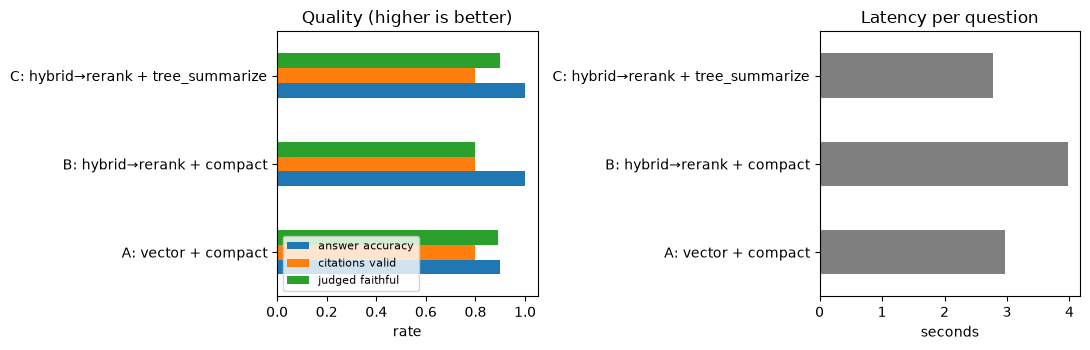

In [48]:
def summarize_pipeline(frame):
    ans, unans = frame[frame.answerable], frame[~frame.answerable]
    return pd.Series({
        "answer accuracy": ans.correct.mean(), "abstains when unanswerable": unans.correct.mean(),
        "citations valid": ans.citations_valid.mean(), "cites right PEP": ans.cites_right_pep.astype(float).mean(),
        "judged faithful": ans.faithful_judge.dropna().astype(float).mean(),
        "LLM calls / q": frame.llm_calls.mean(), "tokens / q": frame.tokens.mean(), "seconds / q": frame.seconds.mean(),
    })


results_table = pd.DataFrame({name: summarize_pipeline(mp[mp.pipeline == name]) for name in PIPELINES}).T.round(2)
print(results_table.to_string())

top_accuracy = results_table["answer accuracy"].max()
leaders = results_table.index[results_table["answer accuracy"] == top_accuracy].tolist()
cheapest = results_table["seconds / q"].idxmin()
print(f"\nOn this run: highest answer accuracy {top_accuracy:.0%} → "
      f"{'all pipelines tie' if len(leaders) == len(results_table) else ', '.join(leaders)}; "
      f"fastest → {cheapest} ({results_table.loc[cheapest, 'seconds / q']:.1f}s/q).")
spread = results_table["answer accuracy"].max() - results_table["answer accuracy"].min()
one_question = 1 / len(answerable)
print(f"accuracy spread across pipelines: {spread:.2f} (one question = {one_question:.2f}) → "
      + ("differences are within one or two questions; choose on cost and retrieval metrics, then grow the eval set."
         if spread <= 2 * one_question else "a clear gap on this set — confirm on more questions before shipping."))
print(f"retrieval MRR: vector {retrieval_results.loc['vector', 'MRR']:.2f} vs hybrid→rerank {retrieval_results.loc['hybrid → rerank', 'MRR']:.2f}; "
      f"judge↔rule agreement {agreement:.0%} on {len(judged)} answers")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
quality = results_table[["answer accuracy", "citations valid", "judged faithful"]]
quality.plot.barh(ax=axes[0], xlim=(0, 1.05))
axes[0].set(title="Quality (higher is better)", xlabel="rate")
axes[0].legend(fontsize=8, loc="lower left")
results_table["seconds / q"].plot.barh(ax=axes[1], color="tab:gray")
axes[1].set(title="Latency per question", xlabel="seconds")
plt.tight_layout()
plt.show()

**Stretch goals**

1. Add a **sentence-window** pipeline (Section 6) over all ten PEPs and compare its accuracy and tokens with pipeline B.
2. Grow the labeled set to 50+ questions (paraphrases, multi-PEP questions, near-miss unanswerable ones) and report accuracy with confidence intervals.
3. Use a **different** judge model than the generator and measure whether agreement with human labels improves.
4. Swap the JSON stores for a real vector database and add metadata filters per PEP status.

### 🗣️ How to talk about this in an interview
- "I built multi-document Q&A over real PEPs with LlamaIndex: a cached ingestion pipeline with section metadata, vector + BM25 retrieval fused with RRF, cross-encoder reranking, and citation-enforcing prompts."
- "I separated **retrieval evaluation** (hit rate, MRR — cheap and deterministic) from **generation evaluation** (accuracy, abstention, citation validity, LLM calls, tokens, latency) and compared three pipelines on the same labeled questions."
- "Faithfulness came from an LLM judge, but I checked it against a rule-based label and inspected disagreements, because judges can be lenient and self-preferring."
- "The decision rule was: best accuracy and valid citations first, then cost and latency — and when differences were within one or two questions, I said so instead of over-claiming."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What is the difference between a Document and a Node in LlamaIndex?**

<details><summary>Show answer</summary>

- **30-second answer:** A Document is a source item (text + metadata + id). Nodes are chunks produced by a node parser; each keeps a link to its source document, previous/next relationships, character offsets, and inherited metadata. Indexes and retrievers work on Nodes.
- **Go deeper:** Metadata is injected into both the embedded text and the LLM text unless excluded per key, which can help (titles, sections) or hurt (noisy ids). Relationships enable sentence-window and auto-merging retrieval and precise citations.
- **❌ Common wrong answer:** "They're the same thing — Node is just the new name."

</details>

**Q2. How does an IngestionPipeline avoid re-doing work?**

<details><summary>Show answer</summary>

- **30-second answer:** Two mechanisms: a transformation cache keyed by a hash of the input nodes plus the transformation's settings (so unchanged data skips splitting and embedding), and a docstore that remembers document hashes so unchanged documents are skipped and changed ones re-processed.
- **Go deeper:** `DUPLICATES_ONLY` never deletes; with a vector store attached, `UPSERTS` replaces a changed document's nodes and `UPSERTS_AND_DELETE` also removes documents that vanished. Persist the cache and docstore (or use remote stores) so nightly jobs benefit.
- **❌ Common wrong answer:** "Embeddings are cached by the embedding model automatically."

</details>

**Q3. Explain reciprocal rank fusion. Why is it popular for hybrid search?**

<details><summary>Show answer</summary>

- **30-second answer:** Each retriever produces a ranking; a document's fused score is the sum over lists of 1/(k + rank), with k ≈ 60. It needs only ranks, so BM25's unbounded scores and cosine similarities never have to be calibrated against each other.
- **Go deeper:** Documents found by several retrievers rise to the top; k dampens the advantage of a single first place. LlamaIndex uses 0-based ranks (equivalent to the paper's k=61). Relative-score fusion is the alternative when score magnitudes carry information; weights let you trust one retriever more.
- **❌ Common wrong answer:** "Average the two similarity scores."

</details>

**Q4. compact vs refine vs tree_summarize — what are the trade-offs?**

<details><summary>Show answer</summary>

- **30-second answer:** compact packs as many chunks as fit per prompt (usually one LLM call); refine iterates chunk by chunk improving an answer (n calls, slow, can drift or lose early facts); tree_summarize answers per packed group and merges bottom-up (good for summarizing many chunks, one call if everything fits).
- **Go deeper:** In Section 8 we counted the calls: refine used one call per chunk while compact and tree_summarize used one for four chunks. Choose on measured accuracy, latency, and cost; long contexts also suffer from "lost in the middle" effects.
- **❌ Common wrong answer:** "refine is always the most accurate, so use it by default."

</details>

**Q5. What is sentence-window retrieval and when does it help?**

<details><summary>Show answer</summary>

- **30-second answer:** Index single sentences for precise embedding matches, but give the LLM each hit's surrounding window of sentences. It decouples the unit you *search* from the unit you *read*.
- **Go deeper:** Implemented with `SentenceWindowNodeParser` (window stored in metadata and excluded from embedding) plus `MetadataReplacementPostProcessor`. Costs: many more nodes to embed and store. Related: auto-merging (small chunks that merge into their parent when several siblings are retrieved) and parent-document retrieval.
- **❌ Common wrong answer:** "It just means using smaller chunks."

</details>

**Q6. Why does `condense_plus_context` work better than plain retrieval for chat?**

<details><summary>Show answer</summary>

- **30-second answer:** Follow-ups like "which version shipped it?" contain no searchable content. The engine first rewrites the message plus history into a standalone question, retrieves for that, then answers with the context and the history.
- **Go deeper:** It costs an extra LLM call per turn after the first (we measured 2 calls on the follow-up). Memory must be token-limited; very long histories need summarization or a vector memory block.
- **❌ Common wrong answer:** "Just append the whole chat history to the retrieval query."

</details>

**Q7. Query engine, Workflow, or agent — how do you choose?**

<details><summary>Show answer</summary>

- **30-second answer:** A query engine for a fixed retrieve→synthesize path; a Workflow when you need custom multi-step logic you control (branching, abstaining, loops, human input); an agent (`FunctionAgent`) when the model should choose among tools dynamically.
- **Go deeper:** More autonomy means more LLM calls, latency, and variance — our agent needed extra calls because `search_peps` runs its own synthesis. Wrap query engines as tools to combine them; keep deterministic decisions (thresholds, routing rules) in workflow code.
- **❌ Common wrong answer:** "Always use an agent — it's the most powerful."

</details>

### 💻 Coding

**Q8. Implement reciprocal rank fusion for several ranked lists of document ids.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  def rrf(lists, k=60):
      scores = {}
      for ranking in lists:
          for rank, doc in enumerate(ranking, start=1):
              scores[doc] = scores.get(doc, 0.0) + 1 / (k + rank)
      return sorted(scores, key=scores.get, reverse=True)
  ```
- **Go deeper:** Sort each list by its own score first, deduplicate by content, define tie-breaking, and truncate to top-k; mention that LlamaIndex starts ranks at 0. Our from-scratch version matched `QueryFusionRetriever` exactly on 15 queries.
- **❌ Common wrong answer:** Summing raw scores, or forgetting documents that appear in only one list.

</details>

**Q9. How would you compute hit rate and MRR for a retriever?**

<details><summary>Show answer</summary>

- **30-second answer:** For each labeled query, find the rank of the first relevant result within top-k. Hit rate@k = fraction with a hit; MRR = mean of 1/rank (0 when missing).
- **Go deeper:** Decide the relevance level (node vs document), use graded metrics like nDCG when several results are relevant, and keep the labeled set separate from anything you tune (cutoffs, weights) on.
- **❌ Common wrong answer:** "Ask the LLM whether the answer looks right" — that evaluates generation, not retrieval.

</details>

### 🐛 Debugging Scenarios

**Q10. Your RAG app answers "I don't know" far too often. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** Retrieval first: hit rate/MRR on labeled questions, whether a similarity cutoff or rerank threshold is filtering good nodes, and whether metadata filters are too strict. Then the prompt (too strict an abstain instruction) and context truncation (chunks not fitting the window).
- **Go deeper:** Look at traces: retrieved nodes and scores per query, prompt size, finish reason. For reasoning models, check the token budget. Tune thresholds on a held-out labeled split.
- **❌ Common wrong answer:** "Switch to a bigger LLM."

</details>

**Q11. Your LLM faithfulness judge marks almost every answer as faithful. Should you trust it?**

<details><summary>Show answer</summary>

- **30-second answer:** Not without checking. Build labeled positives and realistic negatives (e.g. fact-swapped answers), measure agreement and false-pass rate, and inspect disagreements.
- **Go deeper:** The default prompt is lenient ("YES if any of the context supports…"); a judge that is the same model as the generator tends to prefer its own outputs; long answers and position effects bias judges too. Use a different or stronger judge, stricter prompts, and periodic human audits.
- **❌ Common wrong answer:** "A high score means the system is good."

</details>

**Q12. After a "small" config change, cost per query tripled. What likely happened?**

<details><summary>Show answer</summary>

- **30-second answer:** Something multiplied LLM calls: `response_mode="refine"` (one call per chunk), `QueryFusionRetriever(num_queries>1)` (query generation), a chat engine that condenses every turn, an agent with extra tool rounds, or a larger `similarity_top_k` inflating prompts.
- **Go deeper:** Count LLM calls and tokens per request with instrumentation events (as in Section 7), alert on them, and review config changes against a cost budget.
- **❌ Common wrong answer:** "The provider raised prices."

</details>

### 🏗️ Design

**Q13. Design Q&A with citations over one million internal documents.**

<details><summary>Show answer</summary>

- **30-second answer:** Incremental ingestion (parsers per format, hashing, upserts/deletes, cached embeddings) into a vector DB with metadata (ACLs, dates, source); hybrid retrieval (BM25 + dense) fused with RRF, cross-encoder reranking of the top ~50, a compact synthesizer with citation-enforcing prompts, and validation of citations against retrieved nodes; abstain below a tuned threshold.
- **Go deeper:** Permission filtering at retrieval time, caching of frequent queries, streaming, evaluation (retrieval metrics + answer accuracy + judged faithfulness validated against humans), observability of calls/tokens/latency, and a feedback loop that turns failures into new labeled questions.
- **❌ Common wrong answer:** "Put all documents in a long-context model."

</details>

**Q14. LlamaIndex or LangChain for a new project?**

<details><summary>Show answer</summary>

- **30-second answer:** Pick by the hardest part: retrieval-centric document apps → LlamaIndex (ingestion, retrievers, synthesizers, evaluators); long-running stateful agents with approvals and resume → LangGraph; one or two model calls → the provider SDK. They interoperate, so a LlamaIndex query engine can be a tool in a LangGraph agent.
- **Go deeper:** Consider integration maintenance, team familiarity, deployment/persistence story, and upgrade churn; prototype both on your eval set if unsure.
- **❌ Common wrong answer:** "LangChain is for agents and LlamaIndex can't do agents" (both can) or "choose whichever is more popular."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal.

**1.** A node is ranked first (rank 0) by the vector retriever and does not appear in the BM25 list. What is its RRF score in `QueryFusionRetriever` (k = 60)?
<details><summary>Answer</summary>

`1/60 ≈ 0.0167` — one list contributes `1/(60 + 0)`; a missing list contributes nothing.
</details>

**2.** `SentenceSplitter(chunk_size=200)` — 200 of what?
<details><summary>Answer</summary>

**Tokens** (roughly 4–5× as many characters for English prose — Pitfall 5 measured it).
</details>

**3.** A query retrieves 4 chunks that all fit in the context window. How many LLM calls do `compact` and `refine` make?
<details><summary>Answer</summary>

`compact`: 1. `refine`: 4 — one per chunk (counted with instrumentation events in Section 8).
</details>

**4.** What does `import llama_index; llama_index.__version__` do?
<details><summary>Answer</summary>

Raises `AttributeError` — `llama_index` is a namespace package. Use `llama_index.core.__version__` or `importlib.metadata.version("llama-index-core")`.
</details>

**5.** Does `QueryFusionRetriever(..., num_queries=1)` call the LLM?
<details><summary>Answer</summary>

No. Query generation only runs when `num_queries > 1`; with 1 it just fuses the retrievers' results for the original query.
</details>

## 📚 Resources

### 📖 Official Docs
- [LlamaIndex developer documentation](https://developers.llamaindex.ai/python/framework/) — start here for concepts and module guides
- [Ingestion Pipeline](https://developers.llamaindex.ai/python/framework/module_guides/loading/ingestion_pipeline/) — transformations, caching, docstore strategies
- [Retriever](https://developers.llamaindex.ai/python/framework/module_guides/querying/retriever/) and [Node Postprocessor](https://developers.llamaindex.ai/python/framework/module_guides/querying/node_postprocessors/) — retrieval modes, fusion, reranking, sentence windows
- [Response Synthesizer](https://developers.llamaindex.ai/python/framework/module_guides/querying/response_synthesizers/) — every response mode explained
- [Workflows introduction](https://developers.llamaindex.ai/python/framework/module_guides/workflow/) — events, steps, context, streaming
- [Agents](https://developers.llamaindex.ai/python/framework/use_cases/agents/) — `FunctionAgent`, `AgentWorkflow`, tools and memory
- [Using a Property Graph Index](https://developers.llamaindex.ai/python/framework/module_guides/indexing/lpg_index_guide/) — extractors, retrievers, graph stores
- [Evaluating](https://developers.llamaindex.ai/python/framework/module_guides/evaluating/) and [Instrumentation](https://developers.llamaindex.ai/python/framework/module_guides/observability/instrumentation/) — built-in evaluators, events and spans
- [Building Response Synthesis from Scratch](https://developers.llamaindex.ai/python/examples/low_level/response_synthesis/) — the official low-level walkthrough, great interview prep

### 🎥 Videos
- [The AI Conference — Jerry Liu, Co-Founder, LlamaIndex: Building an Advanced Knowledge Assistant](https://www.youtube.com/watch?v=DW5v7MFquDY) (~25 min) — LlamaIndex's co-founder on moving from basic RAG to agentic document assistants; the "why" behind Workflows and agents
- [AI Bites — LlamaIndex tutorial in less than 15 mins](https://www.youtube.com/watch?v=IWyUUrvmb2A) (~16 min) — a recent, compact tour of the current framework, including its document-processing tools
- [AWS Developers — Build a RAG pipeline in LlamaIndex (simple)](https://www.youtube.com/watch?v=vNpxWaVzky8) (~10 min) — a short end-to-end pipeline to rewatch after Sections 1–8

### 📄 Papers
- [Cormack, Clarke & Büttcher (2009) — Reciprocal Rank Fusion outperforms Condorcet and individual Rank Learning Methods](https://plg.uwaterloo.ca/~gvcormac/cormacksigir09-rrf.pdf) — the original RRF paper (k = 60)
- [Liu et al. (2023) — Lost in the Middle: How Language Models Use Long Contexts](https://arxiv.org/abs/2307.03172) — why stuffing many chunks into one prompt can hurt
- [Zheng et al. (2023) — Judging LLM-as-a-Judge with MT-Bench and Chatbot Arena](https://arxiv.org/abs/2306.05685) — judge agreement and biases (position, verbosity, self-enhancement)
- [Es et al. (2023) — Ragas: Automated Evaluation of Retrieval Augmented Generation](https://arxiv.org/abs/2309.15217) — faithfulness and relevancy metrics for RAG
- [Edge et al. (2024) — From Local to Global: A Graph RAG Approach to Query-Focused Summarization](https://arxiv.org/abs/2404.16130) — when graph indexes pay off

### 📘 Books & Courses
- [DeepLearning.AI — Building and Evaluating Advanced RAG](https://www.deeplearning.ai/short-courses/building-evaluating-advanced-rag/) — sentence-window and auto-merging retrieval with LlamaIndex, plus evaluation (free)
- [DeepLearning.AI — Building Agentic RAG with LlamaIndex](https://www.deeplearning.ai/short-courses/building-agentic-rag-with-llamaindex/) — routers, tool calling, and agents over documents (free)
- [Relative Score Fusion and Distribution-Based Score Fusion](https://developers.llamaindex.ai/python/examples/retrievers/relative_score_dist_fusion/) — the fusion modes from Exercise 4, as an official notebook

### 🏋️ Practice
- [LlamaIndex on GitHub](https://github.com/run-llama/llama_index) — read `QueryFusionRetriever` and the response synthesizers; many runnable examples
- [LlamaHub](https://llamahub.ai/) — readers, vector stores, and tools to extend this notebook to your own data

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / rule |
|---|---|---|
| Document / Node | source item / retrievable chunk with links and offsets | `Document(text, metadata, id_)`, `TextNode`, `ref_doc_id`, `excluded_*_metadata_keys` |
| Settings | global defaults | `Settings.llm`, `Settings.embed_model`, `Settings.chunk_size` — set them explicitly |
| OpenAI-compatible LLM | any local or hosted server | `OpenAILike(api_base, model, is_chat_model=True, is_function_calling_model=True, additional_kwargs=…)` |
| Ingestion | parse → transform → embed, cached and de-duplicated | `IngestionPipeline(transformations, cache=IngestionCache(), docstore, docstore_strategy)` |
| Vector index | dense retrieval | `VectorStoreIndex(nodes)`, `as_retriever(similarity_top_k, filters)` |
| Hybrid retrieval | keyword + dense, fused by rank | `BM25Retriever`, `QueryFusionRetriever(mode="reciprocal_rerank", num_queries=1)` |
| Postprocessors | clean up the retrieved list | `SimilarityPostprocessor`, `SentenceTransformerRerank`, `MetadataReplacementPostProcessor` |
| Synthesizers | turn chunks into an answer | `response_mode="compact" / "refine" / "tree_summarize"`, custom `PromptTemplate`s |
| Chat engine | Q&A with memory | `as_chat_engine(chat_mode="condense_plus_context", memory=Memory.from_defaults(...))` |
| Structured output | typed results | `llm.structured_predict(Model, prompt)`, `as_query_engine(output_cls=Model)` |
| Persistence | save / reload without re-embedding | `storage_context.persist(dir)`, `load_index_from_storage(StorageContext.from_defaults(persist_dir=dir))` |
| Workflows | event-driven orchestration | `Workflow`, `@step`, `Event`, `Context.store`, `write_event_to_stream`, `await wf.run(...)` |
| Agents | tool-calling loop | `FunctionAgent(tools=[FunctionTool, QueryEngineTool], llm)`, `Context(agent)` for memory |
| Property graph | entities + relations | `PropertyGraphIndex.from_documents(docs, kg_extractors=[SimpleLLMPathExtractor()])` |
| Evaluation | LLM judges — validate them | `FaithfulnessEvaluator`, `RelevancyEvaluator`, agreement with labels |
| Observability | events and spans for every step | `get_dispatcher().add_event_handler(handler)` |

## ➡️ What's Next

**[05 · Agents, Tool Calling, and MCP](05_Agents_Tool_Calling_and_MCP.ipynb)** — you have now used agents inside two frameworks; next you go one level deeper: how tool calling works across providers, agent design patterns and their failure modes, and the Model Context Protocol (MCP) that lets any agent use tools served by other programs.